# Lesson 144 · ContextGNN: one graph, two ways to rank

Teacher solution · PROVIDED / TODO / CHECK / EXIT. Three live functions: fusion, owner cutoffs, keyed MAP. Tier B full relational reproduction is separate from the Tier C CPU neural fixture. Default execution audits saved author evidence; it does not train the benchmark or establish mastery.

In [1]:
# PROVIDED — default CPU fixture and saved-evidence audit; cloud training is separate.
import os,sys,subprocess
os.environ.update(OMP_NUM_THREADS='1',OPENBLAS_NUM_THREADS='1',MKL_NUM_THREADS='1')
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','torch==2.5.1','--index-url','https://download.pytorch.org/whl/cu124'])
    subprocess.check_call([sys.executable,'-m','pip','install','-q','numpy==1.26.4','pandas==2.2.3','pyarrow==18.1.0','scipy==1.14.1','scikit-learn==1.5.2','pytorch-frame==0.2.3','torch-geometric==2.6.1','relbench==1.1.0','sentence-transformers==3.3.1','transformers==4.46.3','huggingface-hub==0.26.5','duckdb==1.1.3','optuna==4.0.0'])
    subprocess.check_call([sys.executable,'-m','pip','install','-q','pyg_lib==0.4.0+pt25cu124','--find-links','https://data.pyg.org/whl/torch-2.5.1+cu124.html'])
    if 'torch' in sys.modules and sys.modules['torch'].__version__.split('+')[0]!='2.5.1':
        raise RuntimeError('Pinned packages installed. Restart the Colab session, then rerun from the top.')
from pathlib import Path
import ast,base64,hashlib,io,json,zlib,tempfile
import numpy as np
import torch
RUN_FULL_REPRODUCTION=False


<!-- sequence-review:start -->
<aside class="sequence-context" aria-label="Reading guide">
<p class="sequence-eyebrow">From one target to a ranked candidate set</p>
<p><strong>Reading route.</strong> Understand two towers → trace the local and distant branches → replace owner-specific scores → evaluate the full catalog.</p>
<details><summary>Quick prerequisite reminder</summary><p>A bipartite prediction problem links two entity roles, here facilities and sponsors. A dot product multiplies corresponding vector coordinates and sums them. B × N means a score for every one of B queries against every one of N candidates. “Local” means present in this query’s sampled graph, not geographically nearby.</p></details>
</aside>
<!-- sequence-review:end -->

**The win:** implement a ranking rule that uses a different representation for each nearby facility–sponsor pair while still scoring sponsors outside that facility’s sampled graph. Start with the guided trace; use the notebook for the three implementation contracts and your written defense.

[Lesson 143](https://avistian.github.io/relational/lessons/0143-relgnn-reproduction.html) asked what makes a reproduction claim defensible. Its model predicted one number for one entity. Recommendation adds a different problem: **which of many candidate entities should come first?** Better message passing alone does not decide how to represent each candidate relative to the query. This lesson connects the mission’s relational-model thesis to a concrete sponsor recommendation task.

Recall [bipartite graphs](https://avistian.github.io/relational/lessons/0095-bipartite-graphs.html), temporal sampling, and validation-only selection: what identifies a query when a facility appears at several dates? What is lost if every facility sees the same sponsor embedding? Why does a validation-selected configuration need a separate test score?

Recall the three questions above before proceeding.



## 1 · Why two towers leave something unresolved

A **query** here is a facility and a cutoff time. A **candidate** is a sponsor. The task asks which sponsors will conduct trials at that facility in the next 365 days. The graph connects facilities, studies, sponsors, and other tables through foreign keys. At prediction time, temporal sampling admits timestamped rows only through the query cutoff.

A **two-tower model** represents the query as a vector and each candidate as another vector. Their dot product—multiply matching coordinates and sum—gives a score. Candidates with larger scores are ranked first. An item vector can be reused across queries, making catalog-wide scoring efficient. But that sponsor’s vector does not itself change to describe its relationship with this particular facility.

**Worked example.** Facility vector `[1, 0]` and sponsor vector `[2, 3]` yield score 2. A second facility vector `[0, 1]` yields score 3 for the same sponsor. Two towers can therefore produce personalized scores. Their limitation is narrower: the sponsor representation remains pair-agnostic. Do not confuse a shared item embedding with identical rankings for every user.

A **pair-wise representation** instead encodes a candidate inside the query’s context. This can capture a facility→study→sponsor connection and its surrounding facts. Computing a separate graph for every possible pair would be expensive. Restricting prediction to the facility’s local graph is cheaper, but any correct sponsor outside that graph becomes unreachable. These complementary limitations motivate [ContextGNN, §§3–4](https://arxiv.org/html/2411.19513v1#S4).



## 2 · Model architecture: share the graph, split the scores

**In plain terms.** Run one graph computation around the facility. Read both the facility state and its contextual sponsor states from that computation. Use a separate shallow representation to score the rest of the sponsor catalog.

<figure class="context-figure" tabindex="0">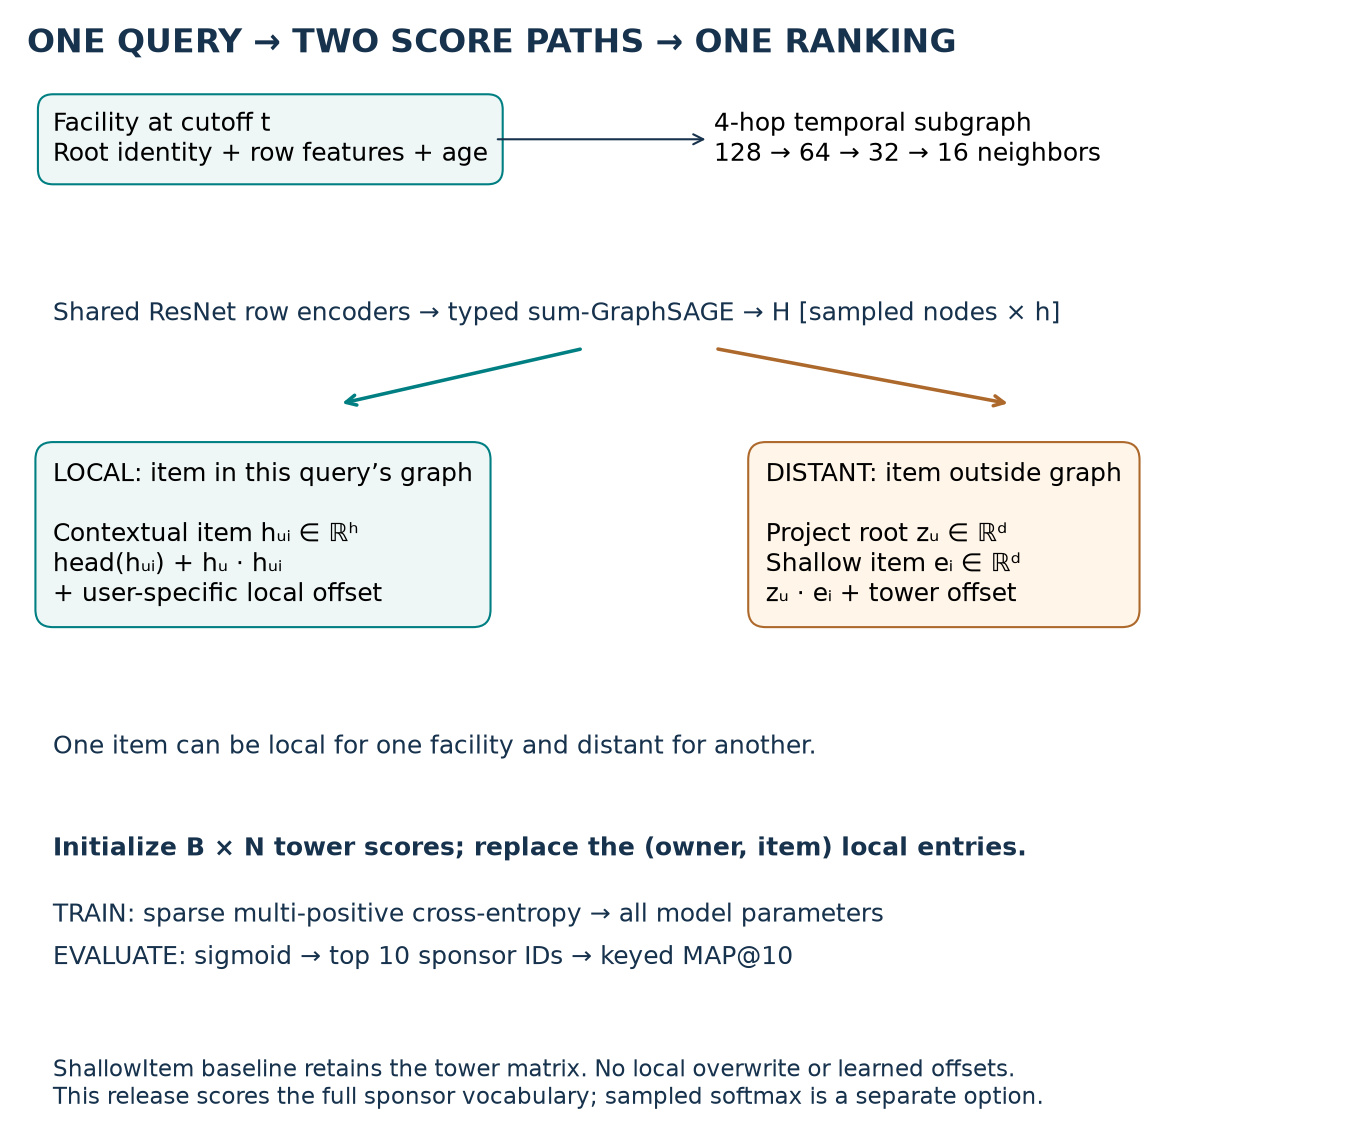<figcaption>Released ContextGNN: one temporal graph, contextual local scores and catalog-wide shallow item scores. Scroll the figure on a narrow screen.</figcaption></figure>

The released RelBench benchmark uses four graph layers for `rel-trial`. It samples at most 128, 64, 32, then 16 neighbors per hop with the `last` temporal strategy, which favors recent eligible neighbors. Sampling is **query-owned**: each copied node belongs to a particular root query and must respect that root’s cutoff.

**Encode rows.** Each table has a ResNet row encoder. A ResNet is a feed-forward network with residual additions that help carry information through multiple blocks. Categorical, numerical, text-embedding, and timestamp columns become a common hidden width `h`. Relative-age encodings express time relative to each root. A learned identity vector marks the root so the computation can distinguish the querying facility from other nodes.

**Propagate.** Heterogeneous GraphSAGE aggregates neighbors separately for each foreign-key relation, then combines relation outputs. “Heterogeneous” means table and relation types retain distinct operations. This release uses sum aggregation, node-wise layer normalization, and ReLU between layers. A sampled sponsor state `h_ui` has `h` coordinates and depends on query `u`; the root state is `h_u`.

**Score outside the graph.** Project the root into `d` coordinates: `z_u = W h_u + b`. The shallow sponsor vector `e_i` also has `d` coordinates. “Shallow” describes the candidate encoder, not the query encoder: the query still uses the GNN. The source supports learned ID lookups, feature-based embeddings, or their sum (`FUSION`). Feature-based embeddings pass sponsor columns through a small residual network; ID lookups are learned vectors indexed by sponsor ID.

> **Scope check.** With learned sponsor-ID lookups, entirely new sponsors have no trained lookup vectors. New query facilities and unseen candidate sponsors are different generalization questions. `FUSION` in the source’s item encoder is also different from the final fusion of local and distant scores.

**Score inside the graph.** The paper explains local pair scores plus a personalized offset. The pinned release makes this more specific:

```
tower[u, i] = dot(z_u, e_i) + tower_offset(z_u)
local[u, i] = head(h_ui) + dot(h_u, h_ui) + local_offset(z_u)
```

A **head** maps a hidden vector to the scalar score. An **offset** shifts all scores from one branch for a particular query. Their relative shift lets the model favor contextual candidates or exploration. Both branches share the graph computation. The full visible notebook includes the encoders, typed graph layers, item encoder, score construction, and trainer—not just a call to a packaged ContextGNN.

> **Source distinction.** The release does not inject shallow sponsor embeddings into graph inputs as described in the paper’s two-tower discussion. Its contextual head also adds a root–candidate dot product and uses two learned offsets. We teach and execute this pinned release explicitly; historical paper identity remains a separate claim. [Source](https://github.com/kumo-ai/ContextGNN/tree/ca4a96985b7ef73c36a40da32e70710ad9b59a1e/contextgnn/nn/models).



## 3 · Fusion is replacement, with ownership

Initialize a matrix of tower scores with shape `B × N`: `B` query rows and `N` sponsor candidates. For every sampled sponsor, replace precisely its `(query owner, sponsor ID)` entry with its local score. A sponsor can appear under several query owners, with different contextual vectors and different cutoffs.

<figure class="context-figure" tabindex="0">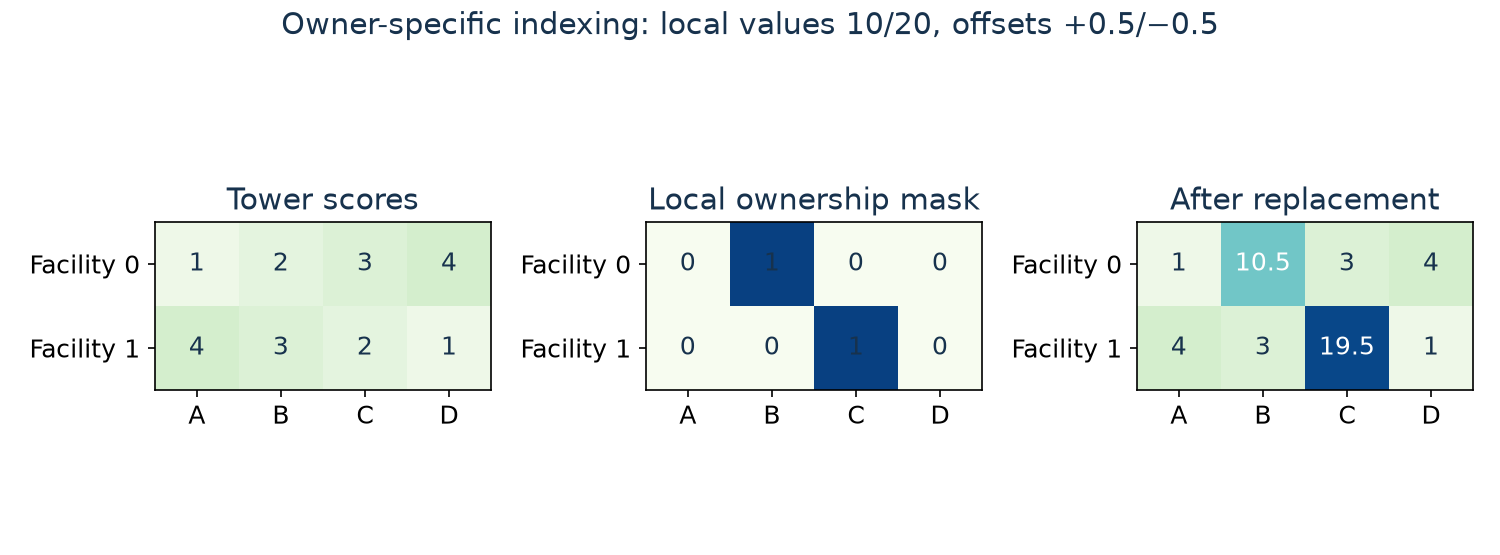<figcaption>Each local score replaces exactly one owner/item coordinate; another query’s score is untouched. Scroll the figure on a narrow screen.</figcaption></figure>

**Predict first.** If a local sponsor’s tower score is 3 and its contextual score is 1, should the final score be 1, 3, or 4? The released operator chooses 1. It does not add the two branches and does not take their maximum. Other sponsors keep their tower scores.

<figure class="context-figure" tabindex="0">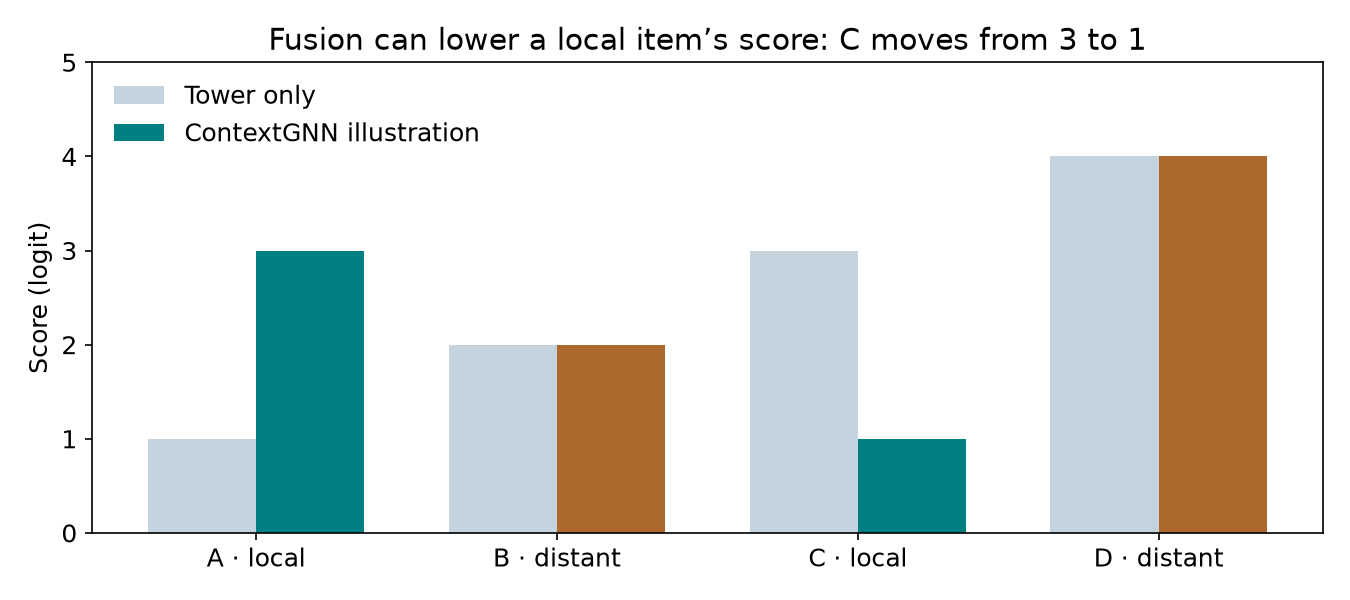<figcaption>Illustrative logits, not benchmark measurements. Sponsor C becomes less highly ranked after local replacement. Scroll the figure on a narrow screen.</figcaption></figure>

Baseline scores [3, 2, 1, 4] rank D, A, B, C. Predict the order after adding +2 to local A and C, then verify with your fuse_scores function.

The illustration holds learned vectors fixed, so changing only the offset isolates score calibration. Changing graph membership is a second intervention. A sponsor outside the sampled graph is not necessarily new or never previously encountered; sampling may simply omit it.

**TODO 1 — `fuse_scores`.** Implement the owner-specific replacement without mutating the supplied tower matrix. The full model calls your function. The CHECK verifies two queries that share a candidate ID and checks gradients: overwritten tower entries must receive no gradient through the final score, while local values and offsets must receive it.



In [2]:
# TODO — live implementation contract
def fuse_scores(tower, local, owners, items, local_offset):
    """Replace local entries; never add local evidence to a retained tower score."""
    if tower.ndim!=2 or len(local)!=len(owners) or len(items)!=len(local):
        raise ValueError('Mismatched score shapes')
    out=tower.clone()
    out[owners,items]=local+local_offset[owners]
    return out

In [3]:
# CHECK — run unchanged
def check_fusion(fn):
    tower=torch.tensor([[1.,2.,3.],[4.,5.,6.]],requires_grad=True)
    local=torch.tensor([10.,20.],requires_grad=True)
    offset=torch.tensor([.5,-.5],requires_grad=True)
    y=fn(tower,local,torch.tensor([0,1]),torch.tensor([1,1]),offset)
    assert torch.equal(y,torch.tensor([[1.,10.5,3.],[4.,19.5,6.]]))
    assert torch.equal(tower.detach(),torch.tensor([[1.,2.,3.],[4.,5.,6.]]))
    y.sum().backward()
    assert torch.equal(tower.grad,torch.tensor([[1.,0.,1.],[1.,0.,1.]]))
    assert torch.equal(local.grad,torch.ones(2)) and torch.equal(offset.grad,torch.ones(2))
    assert torch.equal(fn(tower,local[:0],torch.tensor([],dtype=torch.long),torch.tensor([],dtype=torch.long),offset),tower)
check_fusion(fuse_scores)
print("PASS fuse_scores")

PASS fuse_scores


## 4 · Train on future links, constrain access to the past

The label for `(facility, t)` is the distinct set of sponsors linked through studies whose facility-study date lies in `(t, t + 365 days]`. The left boundary is open; the right is closed. The source joins sponsor-study records by study ID. Preserve that exact label rule instead of adding an undocumented sponsor-date filter. Query rows without eligible targets and dangling entities follow RelBench’s filtering rules. [Task source](https://github.com/stanford-star/relbench/blob/v1.1.0/relbench/tasks/trial.py).

The training objective is **sparse multi-positive cross-entropy**. A query can have several correct sponsors. The implementation consumes the listed positive `(query, sponsor)` pairs and trains scores against the full sponsor vocabulary. “Sparse” refers to storing positive pairs compactly; it does not mean this benchmark samples only a few negative candidates. The release has a separate sampled-softmax path, but the selected benchmark does not call it.

**TODO 2 — `audit_cutoffs`.** Check every timestamp against its own query owner. With cutoffs `[5, 10]`, a timestamp 6 owned by query 0 is a violation even though it is below the batch maximum 10. Your function runs on the actual sampled batches in the full trainer.

> **Scope check.** Correct event-time filtering does not prove when a non-timestamped attribute became available in the real world. We audit the released temporal contract and state the unresolved availability-time boundary.



In [4]:
# TODO — live implementation contract
def audit_cutoffs(times, owners, cutoffs):
    times=np.asarray(times);owners=np.asarray(owners);cutoffs=np.asarray(cutoffs)
    if len(times)!=len(owners) or np.any(owners<0) or np.any(owners>=len(cutoffs)):
        raise ValueError('Invalid owner mapping')
    if np.any(times>cutoffs[owners]):raise ValueError('Future event entered a query')
    return len(times)

In [5]:
# CHECK — run unchanged
def check_cutoffs(fn):
    assert fn(np.array([5,10]),np.array([0,1]),np.array([5,10]))==2
    try:fn(np.array([6,10]),np.array([0,1]),np.array([5,10]))
    except (AssertionError,ValueError):pass
    else:raise AssertionError('Batch maximum leaked a future event')
check_cutoffs(audit_cutoffs)
print("PASS audit_cutoffs")

PASS audit_cutoffs


## 5 · Rank and score the complete query population

**Average precision (AP)** rewards putting relevant items early. At every relevant rank, compute the fraction of recommendations so far that are correct. Sum those fractions and divide by the smaller of the number of relevant items and the cutoff `k`. **Mean average precision (MAP)** averages AP across query rows. Here `k = 10`.

<figure class="context-figure" tabindex="0">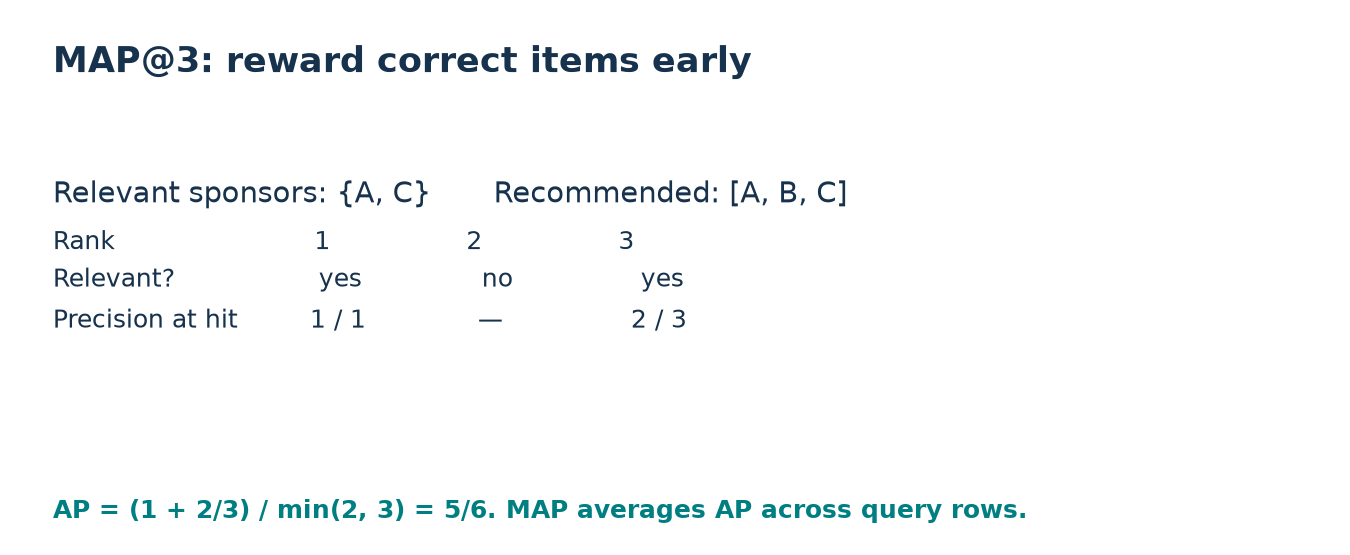<figcaption>Compute precision at each relevant rank, divide by min(number of positives, k), then average across queries. Scroll the figure on a narrow screen.</figcaption></figure>

**Worked example.** Relevant sponsors are `{A, C}` and the top-three list is `[A, B, C]`. Precision is 1 at the first hit and 2/3 at the second hit. AP@3 is `(1 + 2/3) / 2 = 5/6`. A second query with AP 1/2 gives MAP `(5/6 + 1/2) / 2 = 2/3`. One repeated facility at two dates still contributes two distinct query rows.

**TODO 3 — `keyed_map`.** Align predictions by `(facility ID, cutoff)` before scoring. Reject missing or duplicate query keys and repeated candidate IDs. The CHECK shuffles prediction order so a positional shortcut fails. The full trainer compares your metric with RelBench’s evaluator on every validation pass.

The paper reports MAP as percentages: 28.02% means 0.2802, not 28.02 in the Python evaluator. A ranking over a small handpicked candidate set cannot establish the full-catalog MAP target.



In [6]:
# TODO — live implementation contract
def keyed_map(keys, targets, prediction_keys, predictions, k):
    """RelBench AP denominator=min(number of distinct positives,k), then mean."""
    keys=list(map(tuple,keys));prediction_keys=list(map(tuple,prediction_keys));p=np.asarray(predictions)
    if len(set(keys))!=len(keys) or len(set(prediction_keys))!=len(prediction_keys) or set(keys)!=set(prediction_keys):
        raise ValueError('Duplicate, missing or mismatched query identities')
    if k<1 or p.shape!=(len(keys),k) or len(targets)!=len(keys) or not len(keys):
        raise ValueError('Invalid population/ranking shape')
    lookup=dict(zip(prediction_keys,p));aps=[]
    for key,ys in zip(keys,targets):
        ys=set(map(int,ys));ranking=lookup[key]
        if len(set(ranking))!=k or not ys:raise ValueError('Duplicate recommendation or empty target')
        hits=np.array([int(v in ys) for v in ranking])
        aps.append(float((hits*np.cumsum(hits)/np.arange(1,k+1)).sum()/min(len(ys),k)))
    return float(np.mean(aps))

In [7]:
# CHECK — run unchanged
def check_map(fn):
    keys=[(3,10),(3,20)];truth=[[2,4],[5]]
    # first query: hit at rank1 and3 => (1 + 2/3)/2; second =>1/2
    got=fn(keys,truth,keys[::-1],np.array([[9,5,8],[2,9,4]]),3)
    assert abs(got-2/3)<1e-12
    for pk,p in [(keys[:1],np.array([[2,9,4]])),([keys[0],keys[0]],np.array([[2,9,4],[9,5,8]])),(keys,np.array([[2,2,4],[9,5,8]]))]:
        try:fn(keys,truth,pk,p,3)
        except (ValueError,AssertionError):pass
        else:raise AssertionError('Invalid ranking/key set accepted')
check_map(keyed_map)
print("PASS keyed_map")

PASS keyed_map


## 6 · Execute the named reproduction and defend its boundary

The selected target is **Table 2, `rel-trial/site-sponsor-run`: ContextGNN versus ShallowItem**, with published test MAP **28.02% versus 10.66%**. This task is especially informative because both nearby context and distant candidates can matter. It does not establish the paper’s cross-task average improvement. [Paper results](https://arxiv.org/html/2411.19513v1#S5).

The complete released search requests 50 Optuna trials for each architecture, then five repeat fits of each selected configuration. Optuna proposes hyperparameters using validation results; its median pruner can end unpromising trials. Each fit runs up to 20 epochs and stops when validation MAP falls more than 0.001 below its best value. The source also caps training at 2,001 batches per epoch because its stopping comparison is `steps > 2000`. We preserve and report that detail.

The paper describes a narrower search than the source. The release additionally searches encoder depth, item width, embedding mode, normalization, and learning-rate decay. Its Optuna sampler is unseeded, and repeated fits consume a continuing random stream. Our executable reconstruction seeds the search and each fit explicitly; these are recorded deviations, not recovered historical seeds. Validation chooses configurations and checkpoints; test scores never choose settings.

| Evidence | Validation MAP@10 | Test MAP@10 | Scope |
|---|---:|---:|---|
| Published ContextGNN | 28.55% | 28.02% | Paper Table 2 |
| Published ShallowItem | 12.59% | 10.66% | Paper Table 2 |
| shallowrhsgnn timing pilot | 3.758% (partial) | NOT_RUN | 4,096 training queries; first 1,024 validation rows |
| contextgnn timing pilot | 13.250% (partial) | NOT_RUN | 4,096 training queries; first 1,024 validation rows |

**Full selected-task reproduction: INCOMPLETE.** Pilot scores are not comparable with the paper or each other as a model-selection result. Historical identity: **NOT_ESTABLISHED**. Whole-paper reproduction: **NOT_RUN**.

Budget decision: **STOP**. Timing-based scenario at the pilot configuration: both 50+5 arms cost about USD28.75 even at one train/validation epoch per fit, or USD575.03 at twenty; test passes and heterogeneous search widths can change costs. Reserved allocations plus overhead: USD3.35. These are projections, not a guaranteed lower bound or an invoice. Full search is not dispatched when its projected cost exceeds USD10.

An independent interval/join algorithm reconstructed **733,741** train/validation/test query labels. Saved pilot rankings independently rescored: **2,048**.

Real pilot first-batch gradients contain nonfinite entries: shallowrhsgnn: 1408, contextgnn: 1408. Finite output parity does not establish healthy optimization.

The synthetic full-network fixture and original score-operator gradient comparison are mechanism evidence only. The stale RHS evaluation cache is independently demonstrated in that fixture.


**A source-matching failure mode.** The RHS item encoder caches its embeddings in evaluation mode. The release does not clear that cache when training resumes. Our mechanism probe tests whether changing item weights leaves evaluation output stale until the cache is cleared. The reproduction preserves the released behavior. A repaired-cache comparison would be a separate experiment and must not silently replace these results.

The reproduction budget is $10 total, including retries, preparation, and validation. The measured pilot is a cost and correctness probe, not a published-score reproduction. If the complete search cannot fit, preserve the runnable full experiment and mark it incomplete. Never turn a partial search into “full reproduction” by renaming it.

[Protocol and execution commands](https://avistian.github.io/relational/labs/l144-reproduction.md) · [Student notebook](https://avistian.github.io/relational/labs/0144-contextgnn.ipynb) · [Executed reference notebook](https://avistian.github.io/relational/labs/html/0144-contextgnn.html) · [Quick reference](https://avistian.github.io/relational/reference/contextgnn.html).



## 7 · Exit: explain the score and defend the claim

Without looking back, explain why the same sponsor can have different contextual embeddings under two facilities. Trace which final score changes when its owner-specific membership changes. Then defend the evidence status of a one-epoch pilot that uses all training rows but skips the 50-trial search.

Write your defense before checking the reference answer.

**Written defense:** identify a failure that output parity cannot rule out, explain the cached-embedding test, and state what additional evidence would support a full selected-task reproduction. The author’s runs do not establish your mastery. Ask the teaching agent to review your three functions and your explanation; follow-up questions are welcome.

For the primary reading, use [Yuan et al., ContextGNN, §§3–5](https://arxiv.org/abs/2411.19513), then compare the [pinned implementation](https://github.com/kumo-ai/ContextGNN/tree/ca4a96985b7ef73c36a40da32e70710ad9b59a1e). This prepares the next lesson’s question: how can a relational transformer encode the query’s context without this particular message-passing design?


<!-- sequence-next:start -->
**Carry this forward.** ContextGNN changes how query–candidate scores are formed. Lesson 145 returns to a scalar target and changes communication among sampled rows with RelGT. [Continue to Lesson 145](https://avistian.github.io/relational/lessons/0145-relational-graph-transformer.html).
<!-- sequence-next:end -->


## PROVIDED · complete model, in execution order

Read each class alongside the architecture. This is source-adapted MIT code with the local replacement delegated to your live function. Library primitives supply typed convolutions and column encoders. The full model, score construction, training loop, and selection behavior remain visible.

In [8]:
# Adapted from kumo-ai/ContextGNN ca4a9698; MIT, see sources/l144/LICENSE.





In [9]:
# SOURCE: contextgnn/utils/__init__.py
import torch

from enum import Enum


class RHSEmbeddingMode(Enum):
    r"""Specifies how to incorporate shallow RHS representations in link
    prediction tasks.
    """
    # Use trainable look-up embeddings (transductive):
    LOOKUP = 'lookup'
    # Purely rely on shallow RHS input features (inductive):
    FEATURE = 'feature'
    # Fuse look-up embeddings and shallow RHS input features (transductive):
    FUSION = 'fusion'








In [10]:
# SOURCE: contextgnn/nn/encoder.py
from typing import Any, Dict, List, Optional

import torch
import torch_frame
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.nn import PositionalEncoding
from torch_geometric.typing import NodeType

DEFAULT_STYPE_ENCODER_DICT: Dict[torch_frame.stype, Any] = {
    torch_frame.categorical: (torch_frame.nn.EmbeddingEncoder, {}),
    torch_frame.numerical: (torch_frame.nn.LinearEncoder, {}),
    torch_frame.multicategorical: (
        torch_frame.nn.MultiCategoricalEmbeddingEncoder,
        {},
    ),
    torch_frame.embedding: (torch_frame.nn.LinearEmbeddingEncoder, {}),
    torch_frame.timestamp: (torch_frame.nn.TimestampEncoder, {}),
}
SECONDS_IN_A_DAY = 60 * 60 * 24


class HeteroEncoder(torch.nn.Module):
    r"""HeteroStypeWiseEncoder is a simple encoder to encode multi-modal
    data from different node types.

    Args:
        channels (int): The output channels for each node type.
        node_to_col_names_dict (Dict[NodeType, Dict[torch_frame.stype, List[str]]]):  # noqa: E501
            A dictionary mapping from node type to column names dictionary
            compatible to PyTorch Frame.
        node_to_col_stats (Dict[NodeType, Dict[str, Dict[StatType, Any]]]):
            A dictionary mapping from node type to column statistics dictionary
            compatible to PyTorch Frame.
        stype_encoder_cls_kwargs (Dict[torch_frame.stype, Any]):
            A dictionary mapping from :obj:`torch_frame.stype` object into a
            tuple specifying :class:`torch_frame.nn.StypeEncoder` class and its
            keyword arguments :obj:`kwargs`.
        torch_frame_model_cls: Model class for PyTorch Frame. The class object
            takes :class:`TensorFrame` object as input and outputs
            :obj:`channels`-dimensional embeddings. Default to
            :class:`torch_frame.nn.ResNet`.
        torch_frame_model_kwargs (Dict[str, Any]): Keyword arguments for
            :class:`torch_frame_model_cls` class. Default keyword argument is
            set specific for :class:`torch_frame.nn.ResNet`. Expect it to
            be changed for different :class:`torch_frame_model_cls`.
    """
    def __init__(
        self,
        channels: int,
        node_to_col_names_dict: Dict[NodeType, Dict[torch_frame.stype,
                                                    List[str]]],
        node_to_col_stats: Dict[NodeType, Dict[str, Dict[StatType, Any]]],
        stype_encoder_cls_kwargs: Dict[torch_frame.stype, Any],
        torch_frame_model_cls=ResNet,
        torch_frame_model_kwargs: Optional[Dict[str, Any]] = None,
    ) -> None:
        super().__init__()

        self.encoders = torch.nn.ModuleDict()

        for node_type in node_to_col_names_dict.keys():
            stype_encoder_dict = {
                stype:
                stype_encoder_cls_kwargs[stype][0](
                    **stype_encoder_cls_kwargs[stype][1])
                for stype in node_to_col_names_dict[node_type].keys()
            }

            self.encoders[node_type] = torch_frame_model_cls(
                **torch_frame_model_kwargs,
                out_channels=channels,
                col_stats=node_to_col_stats[node_type],
                col_names_dict=node_to_col_names_dict[node_type],
                stype_encoder_dict=stype_encoder_dict,
            )

    def reset_parameters(self) -> None:
        for encoder in self.encoders.values():
            encoder.reset_parameters()

    def forward(
        self,
        tf_dict: Dict[NodeType, torch_frame.TensorFrame],
    ) -> Dict[NodeType, Tensor]:
        x_dict = {
            node_type: self.encoders[node_type](tf)
            for node_type, tf in tf_dict.items()
        }
        return x_dict


class HeteroTemporalEncoder(torch.nn.Module):
    def __init__(self, node_types: List[NodeType], channels: int) -> None:
        super().__init__()

        self.encoder_dict = torch.nn.ModuleDict({
            node_type:
            PositionalEncoding(channels)
            for node_type in node_types
        })
        self.lin_dict = torch.nn.ModuleDict({
            node_type:
            torch.nn.Linear(channels, channels)
            for node_type in node_types
        })

    def reset_parameters(self) -> None:
        for encoder in self.encoder_dict.values():
            encoder.reset_parameters()
        for lin in self.lin_dict.values():
            lin.reset_parameters()

    def forward(
        self,
        seed_time: Tensor,
        time_dict: Dict[NodeType, Tensor],
        batch_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        out_dict: Dict[NodeType, Tensor] = {}

        for node_type, time in time_dict.items():
            rel_time = seed_time[batch_dict[node_type]] - time
            rel_time = rel_time / SECONDS_IN_A_DAY

            x = self.encoder_dict[node_type](rel_time)
            x = self.lin_dict[node_type](x)
            out_dict[node_type] = x

        return out_dict




/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
# SOURCE: contextgnn/nn/rhs_embedding.py
from typing import List, Optional

import torch
from torch import Tensor
from torch_frame import TensorFrame
from torch_frame.nn import StypeWiseFeatureEncoder
from torch_frame.nn.models.resnet import FCResidualBlock
from typing_extensions import Self



class RHSEmbedding(torch.nn.Module):
    r"""RHSEmbedding module for GNNs."""
    def __init__(
        self,
        emb_mode: RHSEmbeddingMode,
        embedding_dim: int,
        num_nodes: int,
        col_stats: dict,
        col_names_dict: dict,
        stype_encoder_dict: dict,
        feat: Optional[TensorFrame] = None,
    ):
        super().__init__()
        self.emb_mode = emb_mode
        # Encodes the column features of a table into a shared embedding space.
        self.encoder: Optional[StypeWiseFeatureEncoder] = None
        self.projector: Optional[torch.nn.Sequential] = None
        self._feat = feat
        if self.emb_mode in [
                RHSEmbeddingMode.FEATURE, RHSEmbeddingMode.FUSION
        ]:
            self.encoder = StypeWiseFeatureEncoder(
                out_channels=embedding_dim,
                col_stats=col_stats,
                col_names_dict=col_names_dict,
                stype_encoder_dict=stype_encoder_dict,
            )

            seqs: List[torch.nn.Module] = []
            if feat is None:
                raise ValueError(f"RHSEmbedding mode {self.emb_mode} "
                                 f"requires feat data.")
            seqs += [
                FCResidualBlock(embedding_dim, embedding_dim),
                FCResidualBlock(embedding_dim, embedding_dim),
            ]
            seqs += [torch.nn.LayerNorm(embedding_dim, eps=1e-7)]
            self.projector = torch.nn.Sequential(*seqs)

        self.lookup_embedding: Optional[torch.nn.Embedding] = None
        if self.emb_mode in [RHSEmbeddingMode.LOOKUP, RHSEmbeddingMode.FUSION]:
            self.lookup_embedding = torch.nn.Embedding(num_nodes,
                                                       embedding_dim)
        self._cached_rhs_embedding: Optional[Tensor] = None
        self.reset_parameters()

    def reset_parameters(self) -> None:
        if self.lookup_embedding is not None:
            self.lookup_embedding.reset_parameters()
        if self.encoder is not None:
            self.encoder.reset_parameters()
        if self.projector is not None:
            for child in self.projector.children():
                child.reset_parameters()
        self._cached_rhs_embedding = None

    def forward(self, index: Optional[Tensor] = None) -> Tensor:
        if not self.training:
            if self._cached_rhs_embedding is not None:
                return self._cached_rhs_embedding
        outs = []
        if self.lookup_embedding is not None:
            if index is None:
                outs.append(self.lookup_embedding.weight)
            else:
                outs.append(self.lookup_embedding.weight[index, :])
        if self.encoder is not None and self.projector is not None:
            assert self._feat is not None

            if index is None:
                out = self.encoder(self._feat)[0]
            else:
                out = self.encoder(self._feat[index])[0]
            out = self.projector(out)
            # fuse
            out = torch.sum(out, dim=1)
            outs.append(out)
        result = sum(outs)
        assert isinstance(result, Tensor)
        if not self.training:
            self._cached_rhs_embedding = result
        return result

    def to(self, *args, **kwargs) -> Self:
        # Explicitly call `to` on the RHS embedding to move caches to the
        # device.
        if self._feat is not None:
            self._feat = self._feat.to(*args, **kwargs)
        return super().to(*args, **kwargs)

    def cpu(self) -> Self:
        if self._feat is not None:
            self._feat = self._feat.cpu()
        return super().cpu()

    def cuda(self, *args, **kwargs) -> Self:
        if self._feat is not None:
            self._feat = self._feat.cuda(*args, **kwargs)
        return super().cuda(*args, **kwargs)




In [12]:
# SOURCE: contextgnn/nn/models/graphsage.py
from typing import Dict, List

import torch
from torch import Tensor
from torch_geometric.nn import HeteroConv, LayerNorm, SAGEConv
from torch_geometric.typing import EdgeType, NodeType


class HeteroGraphSAGE(torch.nn.Module):
    r"""Implementation of GraphSAGE convolutoin."""
    def __init__(
        self,
        node_types: List[NodeType],
        edge_types: List[EdgeType],
        channels: int,
        aggr: str = "mean",
        num_layers: int = 2,
    ) -> None:
        super().__init__()

        self.convs = torch.nn.ModuleList()
        for _ in range(num_layers):
            conv = HeteroConv(
                {
                    edge_type: SAGEConv(
                        (channels, channels), channels, aggr=aggr)
                    for edge_type in edge_types
                },
                aggr="sum",
            )
            self.convs.append(conv)

        self.norms = torch.nn.ModuleList()
        for _ in range(num_layers):
            norm_dict = torch.nn.ModuleDict()
            for node_type in node_types:
                norm_dict[node_type] = LayerNorm(channels, mode="node")
            self.norms.append(norm_dict)

        self.channels = channels

    def reset_parameters(self) -> None:
        for conv in self.convs:
            conv.reset_parameters()
        for norm_dict in self.norms:
            for norm in norm_dict.values():
                norm.reset_parameters()

    def forward(
        self,
        x_dict: Dict[NodeType, Tensor],
        edge_index_dict: Dict[NodeType, Tensor],
    ) -> Dict[NodeType, Tensor]:
        for i, (conv, norm_dict) in enumerate(zip(self.convs, self.norms)):
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: norm_dict[key](x) for key, x in x_dict.items()}
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        return x_dict




In [13]:
# SOURCE: contextgnn/nn/models/rhsembeddinggnn.py
from typing import Any, Dict

import torch
from torch_frame.data.stats import StatType
from torch_geometric.data import HeteroData
from typing_extensions import Self



class RHSEmbeddingGNN(torch.nn.Module):
    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        rhs_emb_mode: RHSEmbeddingMode,
        dst_entity_table: str,
        num_nodes: int,
        embedding_dim: int,
    ):
        super().__init__()
        stype_encoder_dict = {
            k: v[0]()
            for k, v in DEFAULT_STYPE_ENCODER_DICT.items()
            if k in data[dst_entity_table]['tf'].col_names_dict.keys()
        }
        self.rhs_embedding = RHSEmbedding(
            emb_mode=rhs_emb_mode,
            embedding_dim=embedding_dim,
            num_nodes=num_nodes,
            col_stats=col_stats_dict[dst_entity_table],
            col_names_dict=data[dst_entity_table]['tf'].col_names_dict,
            stype_encoder_dict=stype_encoder_dict,
            feat=data[dst_entity_table]['tf'],
        )

    def reset_parameters(self):
        self.rhs_embedding.reset_parameters()

    def to(self, *args, **kwargs) -> Self:
        # Explicitly call `to` on the RHS embedding to move caches to the
        # device.
        self.rhs_embedding.to(*args, **kwargs)
        return super().to(*args, **kwargs)

    def cpu(self) -> Self:
        self.rhs_embedding.cpu()
        return super().cpu()

    def cuda(self, *args, **kwargs) -> Self:
        self.rhs_embedding.cuda(*args, **kwargs)
        return super().cuda(*args, **kwargs)




In [14]:
# SOURCE: contextgnn/nn/models/shallowrhsgnn.py
from typing import Any, Dict, Optional, Type

import torch
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType
from typing_extensions import Self



class ShallowRHSGNN(RHSEmbeddingGNN):
    r"""Implementation of ShallowRHSGNN model."""
    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        rhs_emb_mode: RHSEmbeddingMode,
        dst_entity_table: str,
        num_nodes: int,
        num_layers: int,
        channels: int,
        embedding_dim: int,
        aggr: str = 'sum',
        norm: str = 'layer_norm',
        torch_frame_model_cls: Type[torch.nn.Module] = ResNet,
        torch_frame_model_kwargs: Optional[Dict[str, Any]] = None,
    ) -> None:
        super().__init__(data, col_stats_dict, rhs_emb_mode, dst_entity_table,
                         num_nodes, embedding_dim)
        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
            stype_encoder_cls_kwargs=DEFAULT_STYPE_ENCODER_DICT,
            torch_frame_model_cls=torch_frame_model_cls,
            torch_frame_model_kwargs=torch_frame_model_kwargs,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types
                if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=1,
            norm=norm,
            num_layers=1,
        )
        self.lhs_projector = torch.nn.Linear(channels, embedding_dim)
        self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        self.id_awareness_emb.reset_parameters()
        self.lhs_projector.reset_parameters()

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        # Add ID-awareness to the root node
        x_dict[entity_table][:seed_time.size(0
                                             )] += self.id_awareness_emb.weight
        rel_time_dict = self.temporal_encoder(seed_time, batch.time_dict,
                                              batch.batch_dict)

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )

        batch_size = seed_time.size(0)
        lhs_emb = self.lhs_projector(x_dict[entity_table][:batch_size])
        rhs_emb = self.rhs_embedding()
        return lhs_emb @ rhs_emb.t()

    def to(self, *args, **kwargs) -> Self:
        return super().to(*args, **kwargs)

    def cpu(self) -> Self:
        return super().cpu()

    def cuda(self, *args, **kwargs) -> Self:
        return super().cuda(*args, **kwargs)




In [15]:
# SOURCE: contextgnn/nn/models/contextgnn.py
from typing import Any, Dict, Optional, Tuple, Type

import torch
from torch import Tensor
from torch_frame.data.stats import StatType
from torch_frame.nn.models import ResNet
from torch_geometric.data import HeteroData
from torch_geometric.nn import MLP
from torch_geometric.typing import NodeType
from torch_geometric.utils.map import map_index
from typing_extensions import Self



class ContextGNN(RHSEmbeddingGNN):
    r"""Implementation of ContextGNN model."""
    def __init__(
        self,
        data: HeteroData,
        col_stats_dict: Dict[str, Dict[str, Dict[StatType, Any]]],
        rhs_emb_mode: RHSEmbeddingMode,
        dst_entity_table: str,
        num_nodes: int,
        num_layers: int,
        channels: int,
        embedding_dim: int,
        aggr: str = 'sum',
        norm: str = 'layer_norm',
        torch_frame_model_cls: Type[torch.nn.Module] = ResNet,
        torch_frame_model_kwargs: Optional[Dict[str, Any]] = None,
        rhs_sample_size: Optional[int] = None,
    ) -> None:
        super().__init__(data, col_stats_dict, rhs_emb_mode, dst_entity_table,
                         num_nodes, embedding_dim)

        self.encoder = HeteroEncoder(
            channels=channels,
            node_to_col_names_dict={
                node_type: data[node_type].tf.col_names_dict
                for node_type in data.node_types
            },
            node_to_col_stats=col_stats_dict,
            stype_encoder_cls_kwargs=DEFAULT_STYPE_ENCODER_DICT,
            torch_frame_model_cls=torch_frame_model_cls,
            torch_frame_model_kwargs=torch_frame_model_kwargs,
        )
        self.temporal_encoder = HeteroTemporalEncoder(
            node_types=[
                node_type for node_type in data.node_types
                if "time" in data[node_type]
            ],
            channels=channels,
        )
        self.gnn = HeteroGraphSAGE(
            node_types=data.node_types,
            edge_types=data.edge_types,
            channels=channels,
            aggr=aggr,
            num_layers=num_layers,
        )
        self.head = MLP(
            channels,
            out_channels=1,
            norm=norm,
            num_layers=1,
        )
        self.lhs_projector = torch.nn.Linear(channels, embedding_dim)

        self.id_awareness_emb = torch.nn.Embedding(1, channels)
        self.lin_offset_idgnn = torch.nn.Linear(embedding_dim, 1)
        self.lin_offset_embgnn = torch.nn.Linear(embedding_dim, 1)
        self.channels = channels
        self.num_rhs_nodes = num_nodes
        self.rhs_sample_size = rhs_sample_size

        self.reset_parameters()

    def reset_parameters(self) -> None:
        super().reset_parameters()
        self.encoder.reset_parameters()
        self.temporal_encoder.reset_parameters()
        self.gnn.reset_parameters()
        self.head.reset_parameters()
        self.id_awareness_emb.reset_parameters()
        self.rhs_embedding.reset_parameters()
        self.lin_offset_embgnn.reset_parameters()
        self.lin_offset_idgnn.reset_parameters()
        self.lhs_projector.reset_parameters()

    def sample_step(self, rhs_idgnn_index, lhs_idgnn_batch, rhs_gnn_embedding,
                    lhs_y_batch, rhs_y_index):
        rnd = torch.rand(self.num_rhs_nodes, device=rhs_idgnn_index.device)
        # Prioritize idgnn logits
        rnd[rhs_idgnn_index] = 3.
        # Ensure we always sample positives
        rhs_y_index = rhs_y_index
        assert rhs_y_index is not None  # always pass in dst index
        rnd[rhs_y_index] = 4.
        rhs_index = rnd.topk(self.rhs_sample_size, sorted=True).indices
        inclusive = rhs_y_index.numel() <= self.rhs_sample_size
        rhs_y_index, mask = map_index(rhs_y_index, rhs_index,
                                      max_index=self.num_rhs_nodes,
                                      inclusive=inclusive)
        lhs_y_batch = lhs_y_batch if inclusive else lhs_y_batch[mask]
        rhs_embedding = self.rhs_embedding(rhs_index)  # num_rhs_nodes, channel
        inclusive = (rhs_y_index.numel() + rhs_idgnn_index.numel()
                     <= self.rhs_sample_size)
        rhs_idgnn_index, mask = map_index(rhs_idgnn_index, rhs_index,
                                          inclusive=inclusive)
        if not inclusive:
            lhs_idgnn_batch = lhs_idgnn_batch[mask]
            rhs_gnn_embedding = rhs_gnn_embedding[mask]
        return (rhs_idgnn_index, rhs_embedding, lhs_idgnn_batch,
                rhs_gnn_embedding, lhs_y_batch, rhs_y_index)

    def construct_logits(self, lhs_embedding_projected, lhs_embedding,
                         rhs_gnn_embedding, rhs_embedding, lhs_idgnn_batch,
                         rhs_idgnn_index):
        embgnn_logits = lhs_embedding_projected @ rhs_embedding.t(
        )  # batch_size, num_rhs_nodes

        # Model the importance of embedding-GNN prediction for each lhs node
        embgnn_offset_logits = self.lin_offset_embgnn(
            lhs_embedding_projected).flatten()
        embgnn_logits += embgnn_offset_logits.view(-1, 1)

        # Calculate idgnn logits
        idgnn_logits = self.head(
            rhs_gnn_embedding).flatten()  # num_sampled_rhs
        # Because we are only doing 2 hop, we are not really sampling info from
        # lhs therefore, we need to incorporate this information using
        # lhs_embedding[lhs_idgnn_batch] * rhs_gnn_embedding
        idgnn_logits += (
            lhs_embedding[lhs_idgnn_batch] *  # num_sampled_rhs, channel
            rhs_gnn_embedding).sum(
                dim=-1).flatten()  # num_sampled_rhs, channel

        # Model the importance of ID-GNN prediction for each lhs node
        idgnn_offset_logits = self.lin_offset_idgnn(
            lhs_embedding_projected).flatten()
        

        return fuse_scores(embgnn_logits, idgnn_logits, lhs_idgnn_batch,
                           rhs_idgnn_index, idgnn_offset_logits)

    def forward_gnn(
        self,
        batch: HeteroData,
        entity_table: NodeType,
    ):
        seed_time = batch[entity_table].seed_time
        x_dict = self.encoder(batch.tf_dict)

        # Add ID-awareness to the root node
        x_dict[entity_table][:seed_time.size(0
                                             )] += self.id_awareness_emb.weight
        rel_time_dict = self.temporal_encoder(seed_time, batch.time_dict,
                                              batch.batch_dict)

        for node_type, rel_time in rel_time_dict.items():
            x_dict[node_type] = x_dict[node_type] + rel_time

        x_dict = self.gnn(
            x_dict,
            batch.edge_index_dict,
        )
        return x_dict

    def forward(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
    ) -> Tensor:
        seed_time = batch[entity_table].seed_time
        x_dict = self.forward_gnn(batch, entity_table)

        batch_size = seed_time.size(0)
        lhs_embedding = x_dict[entity_table][:
                                             batch_size]  # batch_size, channel
        lhs_embedding_projected = self.lhs_projector(lhs_embedding)
        rhs_gnn_embedding = x_dict[dst_table]  # num_sampled_rhs, channel
        rhs_idgnn_index = batch.n_id_dict[dst_table]  # num_sampled_rhs
        lhs_idgnn_batch = batch.batch_dict[dst_table]  # batch_size

        rhs_embedding = self.rhs_embedding()  # num_rhs_nodes, channel
        embgnn_logits = self.construct_logits(lhs_embedding_projected,
                                              lhs_embedding, rhs_gnn_embedding,
                                              rhs_embedding, lhs_idgnn_batch,
                                              rhs_idgnn_index)
        return embgnn_logits

    def forward_sample_softmax(
        self,
        batch: HeteroData,
        entity_table: NodeType,
        dst_table: NodeType,
        src_batch: Optional[Tensor] = None,
        dst_index: Optional[Tensor] = None,
    ) -> Tuple[Tensor, Tensor, Tensor]:
        r"""Forward function with RHS sample softmax."""
        seed_time = batch[entity_table].seed_time
        x_dict = self.forward_gnn(batch, entity_table)

        batch_size = seed_time.size(0)
        lhs_embedding = x_dict[entity_table][:
                                             batch_size]  # batch_size, channel
        lhs_embedding_projected = self.lhs_projector(lhs_embedding)
        rhs_gnn_embedding = x_dict[dst_table]  # num_sampled_rhs, channel
        rhs_idgnn_index = batch.n_id_dict[dst_table]  # num_sampled_rhs
        lhs_idgnn_batch = batch.batch_dict[dst_table]  # batch_size

        (rhs_idgnn_index, rhs_embedding, lhs_idgnn_batch, rhs_gnn_embedding,
         lhs_y_batch, rhs_y_index) = self.sample_step(rhs_idgnn_index,
                                                      lhs_idgnn_batch,
                                                      rhs_gnn_embedding,
                                                      src_batch, dst_index)
        embgnn_logits = self.construct_logits(lhs_embedding_projected,
                                              lhs_embedding, rhs_gnn_embedding,
                                              rhs_embedding, lhs_idgnn_batch,
                                              rhs_idgnn_index)
        return embgnn_logits, lhs_y_batch, rhs_y_index

    def to(self, *args, **kwargs) -> Self:
        return super().to(*args, **kwargs)

    def cpu(self) -> Self:
        return super().cpu()

    def cuda(self, *args, **kwargs) -> Self:
        return super().cuda(*args, **kwargs)


In [16]:
# PROVIDED: compact pinned source and author evidence; not learner results.
SOURCE_FILES=json.loads(zlib.decompress(base64.b64decode('eJztff932ziO+L/CS3+I3HGUpDsznz2/877LJG6b2zTpS9Ldz7zET1VsOtFEljyS3Cbbl/vbDwC/iKQo2Uk6e3M79c6mNgWCIAiCAAhSXzaODvdHx2ejjQHbeHd4zo6SCc9KfpldZvv54r5Irm8qFkx67NXOq+/Zz8lnnrGfl3GGAO95MU/KMskzlpTshhf86p5dF3FW8WmfzQrOWT5jk5u4uOZ9VuUszu7ZghclVMivqjjJkuyaxWwCDV1mAFrdAJ4yn1Wf44ID9JTFZZlPkhgQsmk+Wc55VsUVNjhLUl6yoLrh7HLjTFa53OhRO1Mep5eAnOFj9ZB9TqqbfFmxgpdVkUwQTZ8l2SRdTpEO9ThN5olsBKsTB8rLDNAuS+gGEttn83yazPBfTn1bLK/SpLzps2mCuK+WFRSWWEjc7GNftvOClTwFwgBFAsRTh2v6CAipXyBbK8moEks+3+Rzuy8JUDRbFhk0yqnSNAfGUZu/8EmFJQg/y9M0/4y9m+TZNMFOlQMcunN4GF/lnzj1R4xylldArqACB2JRD698VN7EacquuOQatAw8js0uFUhBWYEIJHHKFnlBTbpdDYmEtyN2dvL6/O97pyN2eMben5787fBgdADjuXcGBZcbffb3w/O3Jx/OGcCc7h2f/8xOXrO945/ZXw+PD/ps9P/fn47OztjJ6WV2+O790eEICg+P948+HBwev2E/QcXjExDpQxBswHt+wrBNietwdIbY3o1O99/Cz72fDo8Oz3/uX2avD8+PEevrk1O2x97vnZ4f7n842jtl7z+cvj85GwEBB4D3+PD49Sk0M3o3Oj4PoVkoY6O/wQ929nbv6Ajbusz2PkAHTpFEtn/y/ufTwzdvz9nbk6ODERT+NALa9n46Gom2oF/7R3uH7/rsYO/d3psR1ToBNNA9hBMEsr+/HWEZtrgH/+2fH54cY0/2T47PT+FnHzp6eq7r/v3wbNRne6eHZ8iT16cn76CPyFOockJYoOLxSKBBfjNrYAAEf384G2mM7GC0dwTIzrAy9VJBw7jCoG2cjvYO3o3C+RSVyosXbD8HjXBXvTk+FqIHslXwRV4mVV7co2SiKijZ+/vzvJjcsGS+SHk900F2agQkOYDybf4ZZfx0SYroPEeERT5dgpDC9F6mFchcxk55+hPPJjAvi2XGPl7h93lc3G4XPKUfUZpkt9Gi4FOhDyINEi7uP1JjHz9+LG8us8U9aIeMPRIF29oCTcFT6iT04DoTGLuIPvyv/b3DLepyWTUor66rKPllEiePINVfZxVt0G7NdyQMtbfiKJvGVVxyoE+pzWqJ2lzSy+9iHMSy5pIsaaG1Cx7olI0Bl9ItUK+gWba2oOSWgQjxrXIBKiYvtrDlR/UJSWcltTMVep7doPYrkykHlTflpexOjS0S4BEuUvP4blV3uioCrcVNqcuTf3C2u7Ozo+kFKT/MQJWCxsV/iyWJl9lYsgD9KyC2OBNTA2cF0qxIIHWuh71s1NoML2bLNB1vynZx/tZUb0cRLNJVFAG9OJmdpzguLsisgLUqFOI2EUKMMxpWAiHZkZRspDaKgIooYkM2SWGlB2qH7GLTAtscN2iiVq0GZNOymbwMFzGMbAzTqVyAHSCKF8nkNiXDRhZkyzmMAkBlBhCwC0rgv8VUF5aTZHEflou4KDk+MpBWqLFgKcZO0/doVsRzrnpcVvcL3nwcYhcUzIEQbgvqmudzjkaKBfmWV7zIEb4FeFklaanbhj8Rn15zGJ8pv7sk0SE+2wMR9MAiYPApLjfwf/SQyYeKulCAnOXLYsIH7KaqFuVge/saZtDyKpzk8+34Nr5Lb7bP35xvV2D5bc9Bp2/L2qUYLolENCO+T/mMKQEKwDqagS0FY6dIws8kTyMQ16qMUMOChHx5qB9OyyqimQrlx3nG6ydVkR3FV6AK3AdX/EbI2QSss9vNPtucxZ/wn0lcVPjv1fIepU7Bl8UkgsUoqe6jKr5KOdTdBEuw2LSpcEFAM81NEBzHoTGEQa9+OAO7KUFbCmznax6kPAuQyp7JBkl6/CkB4CH14iIZ289JoeULqA6CH/6SJ1mA3IQ+ATeiTfadxgB28mZxtdlDcZ6VTjP4mcfIajFnwjSPp8Gs7NlgyQyIHg7Zjqe60thDJUBBEwY/i2mIAK9xVgRfLjcinNLAzegSJnS2CGHkygBoCcH0XPCLnXHvodf3o0I5qfKIptzQRUWlIcx4DvMkTh96rSSH0BrHNQYUctACdiEEYBxWM+ihqlhxXIbEDG/Ws8VYYTCqa4B/Gjd3fy/cpLnyLG4KDOtzU49gFiVTqEaaNIzF/DPlrYU9nZ8pMU2gTPPselW/u2nY/S1oMIcXVerlRpUAn/XY4i9g33zxYNdrSqItc5tYcXOA6oOWrlb58pMyNH/0vE13SZQjFUrZrSEXNB4afl1JdGtB3/U4ilqBYkR/1Yg4uO5cRGr64uKgkPZ6vfBTwj8HW7t9ttuN0CdkFq6VFE7yPBLLAiwu8keR3CGG5spQL1VDsaL6Fglj8Zb4mkDGOr7LXjJsjf0bLDpOk9AedPDO10OJes1eohESTgoOUkbWUyBGT/Wnr1rqNwyDVZJuDaciqsg/e0h6Mk2uJfIkmmCOrKbphWHLsPzqFw/FSGUlJ5LvsTH8+rsHzpAA9dXHHtdMtAvQ+EVYNDhNTgqbs5Wfi1t+H2Uw8eVXKDSNshdsBqVs6y/0lCFGowe18a3FEgia3AYXNn74NsbQ4XxoSjXVlvo5qEmbXW7MXi2iL6rkAeNkmkyjPs1/jWQcWtQ4zkFQf+0pTon+LWT/Zrp/ofn4cqPgn8AmwABwPMWIYImRRxj29/dvGNqNvAC3fZJfZ6CvSxFR5Z84elJrc0sxSY/LKm4ZozYTFDZZpi3hr8Exx0NtOs7CKwY3PEeGWP7cSBRKly7EmACfX/EpBaUl5Onbs5Eqa3ecLXzoyZjVPI40/CcpMqmEvhst72X3fXYAE6jPjhKMR50sMAyB8XXXCTZ/qdWydlMVwnPSNS0+cUgTVoGewY9zvwOdZSEFejTsKS+PW53oLFNg7zHqSPQTm4id3io2F46hLUHJZXYwer334eg8Ojv/+f0oGh3vnxyMTqODw/3zATHqwqSTDJk+cnFMZlamla4EmIAmus7JjB6wwOmiHjw5pn3wfZVBZYEqS7yJ4ijJeFysqD9fplViU2I40jbCdwi7X8M2aKxrfnmQP3xtahlvpXnNzmtTtYnoXD1yUIBRezbaPzk+OIsOj6O96GDvZxidH3fAvqA/r743oyXWtBJNECPy6TLlTvBEwJ7hqP89KflITXjQjqykwDZTSqDK5VdG7MfAZSwXNgoWkFhOk9mMF7CiUzwS5yYpYAG2V1ybrvvkJs4ynBJBklW9AcM9nnxZLZZV/QgjDTyG2ajRGeocy9D6xpUTtadcSgOSajUF+q1CjvrhoqyK8XgMrcPikOW/xgM2+mFn116v95iMlcfFPXgKC5pp1F1NFXIHyFjOM0aUGDVco3S+iKsEgy5QRW0hkDfS0jOhYrydAuLlN6V6xNTFDj2nC9gkMCeZPLcfxOlISlA0Scvo9nMMUiC706J51id+AIbc4GMDzUc08HBbMcFtUMeWq5Yo1eWCT5LZPWIa0LSx0cB8oUkhJ8RHsW5RcDpxfTFYvD/nxZRBx2jDt5Rkia5+DL2qKaLlAFkyYO/EFgC1gAJvc5PmhXgoeuV0J74FcVN9EKsVVdRMiGHRyXBWIfVigjk9EPSqSfdxC4wVwEPLDtN6rwzZAZ/FMPehH059PwfFGtfNAEseSJ6FBLC/Nrg6w2V4RbM1W+WQ1US7w0R70iY6jBMIsUgmNA4rusVGdwsSsiZDrjipsGuwLxFRrRW7SV4VcDYmFroBTVU6QInvr9KQct1fqSGfEMaBj6FWWyghjeYnol2j9VdrlW57pr9iHg7FuHaCqXaUUXlhi+1YBu+VGYGOCP429Fm5XMCi3Av1mFr+C3mGsmOldiv04o2t2RVQugRrUYMnWcuIhyD8ZeDqVZuPareiOeoE54mHtI3DBT0YX+yMW+K+L1+uqro79gQhsbNld0cvNDPGss82mgeTeQ2OG7UV810p8fTo5cs2QfHMINC/kZqtQ/XFA6fnybAxcwwqWyrW/BiuZJMHRVMuhs0ip17PDFgUHHRptIiRIWBflhS18M0GMu+UzZnZgxF+itMlb0qtcgEbjVgkAGYYgmm7yqxmfl1oag9jNR2bc9qpIsDGBp13LbNJs33QKnhBNXNk1prjQOAMWSXJDzEkb0m5EQAveLUsMklM00M45+gsSs+y3VPwbHlqakAVkrpXvBj37aXoeRpQMdGnBVsZa5c3/edAEdjF5VrBYCcN5vYcStMk+wpU6qrCk9Qk1tx8KrFfd04KkXvCvDRxA8s0XsW+Npzw/LnzvOR8GqHPPZDz1NQBUOzXAnJKG7BXcQV6YQ3g9TQErgNdyGTeQMtK3yfSSQ+oLihN4HCwgMVI7vNoTlzUfTEUz5htEbbW+vrrNnOjEe6qSgFIV3BMJadw9VrqKcEw69w5wIqF9qp9Z9IiNaCC9EUURVjOH/+8LuLFTRlfczsC+gaLz/bejFQMNJle1yG7wwNKHBRP6rbUYzO5UMBQlmr+ubgpDbAzUXj69syABBDtjhmwZthUJi16A66CL5tOJzDwSjTjl5o6/GURsSnle9NpbvMy84ZqJWPrwrWCtsqyhomAfjr8I8OYbQlM/5tx2kclO9Xj9e7o/SOjuO3ZU+E8Xih4+KpypwwmR8B94c3XDIAphjwlKGOA4D8n5C/1ansMWQqFFXO0yhwrA571vA3bbPdPNF+NtSeFi8FKPjOhMRxjWkv1nAgcpG4mWkciMCNqw8e79ihjA0O6TK/f2jEcuB70Wr603L4ht2XQYINJh7NTi5kX5lqaLediR7QRg4AHaXwPK7f7pC1qoYcT+jV3H8bX1wW1jUlr5XK+aQUZirl+Rm1GWLS5yvUfkJa5cCw4XE2+ekxA8dxIozWqQlefEkMQ28G2OPStoX3cTrsey749Fq2Wus4UVL6EEyxe4fD6ndShJxRhOFC0+2m4+5XYU6/r+wMIltlMa4PPdsbPQweVwjV3ON4VXalDHMOVylR9/GEqb+nKmrLtNSIVrotTSQUeuWPt+o8tvk45vOgYx0eOCX6SGVPpXwrekAMb3g1vdEmi23FcTIbuStTeS4dup2G9TS8B69+PoBA/qP+G+MeVTq1mh/XXjt7d8Bjzq8AWaZmsDn4rcLXbmBrFfIh/2ona7aAlBU21KHLcraBk4XZ/eIU6SqZRjAe2Ml6S7jNx6YUt2PX61drvyGcz9DiFUd8kxiLBTmNzUQDo03Do/c+hptSBQM6iglcJSVplO3DukY2hu/o0eNjtb68dRlCLVFc4wFxCVgO6imh1DTTzVgLhRFgN5UrW6hpWYsxq8IbYPKoKCesaNcyJtmKklYxUfCHDftgjakh4GX2W6gKKKAgI/Kn73WJlYMV7s9K9TE0yBKjI6vzPIs6mQVPuwarhn5IJHzqUhaLY6P0L9r5I8iKpcA6ImZ3m19ZWLrR34eBBW+xPVv7YKCuXeDSXszj9HN+XkkuMTgcmn8zpZ3RLzrp75Z0pEPTMwfkwIZMSD6/SZML2ZCsL9ENwrcPDSTYORfZ9TfL3oU2FpiGbhlW+uA18mqFPGWN8OjwvlrwXQh3goNEdOkJbQhftzlAuTxr02H8MvQrHy48+uKrlLSDSHmtgPdVEr70FOY/vRI2hR0rWRaK7ONTfDBEyZBYoN3/hwRLNHVDV3Hx6gV0d22yo8+WGHl0R6O73KCvFlni5HvgHJvCNzHfuxFVPWvjSMpI9R6hMReAdTgvi8UO6ekSA7zhX9CM3eGxrJzloRok7NKprlgaT4m6VNcZUhBn9va51YUNfNlnRVKDtutJKEc7lkctIqDWpsVOzfaX58bID60HXkHgIenSnLGQGf0xtL9Y8Sb0cKg/l7D/t5kPzaBFNFxHbFhrNmjp2nrDIucH0XhEBirMJ3f6gMW9h0KY+Jl1nogFlZPY3aJdLse6Cf1kPmkLq6WcvnKVxVfHMnKU2j74behu2D1iYXd6P08kSsLYtgGJkbPLROApWzBCDVqWv5CFlZL5JwU98Ei9LsXzCKppn6T2b5jjJXrGbfNFXD3BWFzxO4TFhophoNssp6ctEiGNR4UUeMDqcqmdc3C8BSiEv0FyE7tLtEFi/mIvIHGgLTKS18Biz25HoMXvZ7HQL22BQugbYh7rJMo+Sb2F8uZx7EhIw13xrt3tYjDbWmRaHB4+YD6KDq6YDQT1jNjjiag+Dj4YG882uW3PLhWyYvmOnwcZSYKHz7FdGdt+dmC812hL0tWOwet9QRgtNB0xt9+HpW1ruzKrjUD+vq+i0BdMxC6hyKBMOHJ2yN52ibGjXSF3kUuR55UiFQG4TcTHQVISosoOdx1gH2OExTjm/h/aZ4xUJ5tCIPUerk65TGWiC+kx2XFV5dD6cqF9vtrZnbvXrzVU8VW0S2rKve+fb+myUfadxmU3bw9ychXe+7orO1KdIXJheYw7UeSdYuNZm/ZMFn1ooq7ZpgfEJsUH4NSeIOZelnjAxWMNdmyXmTrwUesfLMG1P/6x5pCTWjY9dE6mx0rQZXkNPBCGwgB0HwbWiZU/0KI3XW/kczavGis6HroHR7pjtDrjz08FUs8lKKVjtv63ltrkGrzwU6JjxbQb8Y1WRbe+vHadp/zzdCWhFZ3oGj19Q7ftq/ukqhloqJpFEr3f06nQeZxMQUVFfVwEL5YXJEPK5yhHypRXJnejXgilstsyEtUY3bZy+PVPxKnWtj7kfLZj1TSd+04mP1YmPDnx0K6DWiIdiuBmadpt+rOZpYcWT8TxftaqPVif9Wlm0RgO+LSCPWUDao2rm0lLlMoz2krbI2cuXYrOcNDLmUA0arahdL6jqVrLCdYtlvXHWjQlB7brLafxkuqhyk7LW7D2dAdmevFcftn5imp4vRU4sz/t59glQ4wbyMW4uM9yBx8K10udG4KuIrCfzOLSdA1/v63efk22mdumaGHv9lKfLKk+yJ+R3deTSG3NdZwtIINU3E6gtncrMmLrcmPM4u9xoz88CoFfPO7+E/PAcXkK63VzwqL5ErCbDdXURn07EwNH3hLw8qUIW3wZadFqOJOHHl3dff+3XqRctOycUEtP3OkDP6mFrVnCzi/BDDVxulMu5NUL48d6wgowO48WCZ9MAfzTHAnMyvuZYIL6uAw/rn1Pw2GsauR3W0PPfGB9UT8ApijBt+HhDHVe80Yg9wurLtKjn76NOTZCgqqMNNDgeSV55PqJmsUJFfRn4OFvMBVNljbZjFIq5zz1LcbfuYQknTPRVTkzQpYN9RoLer/vco4lGN0rEFQ/+kYhsBcH/vsHAxu2E2nFB0EAGtFzS3QMK+mDXLb8fGBILP/GEAlEJ3/vsDum6s0J4D5247mB0UljrV6FojbO1LuIiOeSR2fff0u7/j2XIG9el4mmORxs0VOv3mqb++CRyM1/xXyyH/HmnKr/lan/L1f6Wq/3HydU2fzw7bdsh7Nn51l8r2fhfLJH4ETb5/60t07acAgX9LaOg8/NHyyhoxjF1Ulpj66QrjOmcEV3DF+ryfR7n4azrtzz/sG67seKtvcbNnU8+M+sclF3rbpH/Ld/itz8C23qgtbfCgtfP1rip6XbAPuGVS54Q3G2fUWCqXUCa98jgB6y3W222ub0fX2xWs81x6L1pqsbzYA9r6OZPmPx2tIYalKF1krUBU7N2aJ+raho1NDrD+nirG57zOwvNrnsqGr7QI9jV6Yesd/PSjMfdTfpUart15VpVq48x1Rgfs2H2Aq/PS5NJUqX3bIJv9/lY5R+ZfIsdpirUUgImwJze/RZPbriyCExU4rxP2Em6d0tOwX+97TtPy3ILr6WtZ27w+drzb/K1tf/ILUHrupJvUcWnXubx7W6Or3E3h3VDzaOv57Bq/15Dn99u6PgdRlf/iTdumFL3LYb7LYb7LYb7x4vh/m7u27DQ/G6iv3/0qyYec63DHySg/C2kvObnjxtSfuTxA3+2v19gjMMFzgkAA5FzaKjhoKt29ZH3sHp6uOVfLT/Zjni0RiFWvQNq/dCD/fy1+7ooHXKo4xL34p06r3kMXVRvEukKU6Dmzrh+/fTrffBtkukyTn9K88ntUwMHT4rZr8geMkHRbwYI0hXgRpdP8KDXcm87fc5W39Z434SjC9x3YjiPm3HXBghGXhunt8Rt8Y5LuW6Yn1Y0yQw21HyxoqZEkXgznXxdz0xIWIkhjZiJNzqLN9+w8gYWm6kRSi0XcTNQKntp9KVFelW/nPpaHRoYtACd8V+XqB7jtKV2hPTDI/ynfgReh80OWHM8jo0rMOHr0d75h9NR3/Pkw9nhyXGNYuysVo6D3cICT/64Zap3bUFYAll7sy1QhmfeuWlAtD9h48BaDAUDflXnCzyBlgvH1YMBooFLStceV58iBu6xv2FO8qgoYLGcNTUHZ1+sYX5g5nHE1g+9JvHXZYJST1SQk+dJBf+V7uTwCI6jXd0r+WzHx8Px59Qft1BZ+2E65d1FuwDPjm/9v14DhTkNTUesnn7BS2yomcST5vntclGvpr5JrMesOYe9E7Ux+Y5OTv764X3rrPTORZcwv3/Ztpv3iE+nlxvRrhMdnPTyyD60+9t4uIrHDY4Y18Wtw8FOV1IPZP0SwC7c67jGCmUtme1I6QTFTZJO9bmH2qWl8gLvf/GoGXq42kn2jqMetaaDLEzY7iPafqdW3ksmXDdQghkKTEN5dhDVziT8mKkw3vp1FViZSkd1P0GU6H47eTlhC03YkDpt45c84eg6+hkvy3sGtgt52ngwXk+M6Q14awukvJ3RsFEMWHftXI9HbtSixt272Bmvy5t2LIIh4yYyo1btu0KhMx4v2GxZcl9VoXjxvin4LV5n7L7A3Rw1GzXMTXwDHxAg6puBQMnlpEyykq6bCgS0OgLUvO+va151znSBuOF7quKnOda/bR6D1hOu/Hn7LQ3p+sc/K+nhuWT+phkSzybuN0inIKfcfemMJzQRYgUpxPXO/5sUpOgcnripeqFIPdDufjBRd/5FN9AQnpCL8iwCJ7AoeVQBbbw9Yuipm00n1z0dZMBTd/qwNXxvCyagnRcggBNFOBMv24SZcJN/di/tk2kmNIMKvsDlXe7c0024aZLdCmTGnXRVXN6q972bUYgX7AM4IqQyyDnG5WRruTDebcoCeJqV0+UEb/FVdAqjlbaqaQHaVOjegz8I053+QLsmreJVq9olD0Aj20ilg4pYJZRG+xovR/QQR8tWRxs+2oVdTa0sMU60KUaHbnYWwz+PQVbucIdVFkxy0HuTJLKeO2OGR6hBX5cMABf3EhUToDiEsgBQyUIrHGRgR4ghazQHWgjJ0NP9BXvDK1KlYsu9ABbIu4n7xBcZA7HuKxbHYPWqVdFCEtiNhwLfFL1ksU0bJln14/dyZkM7kcS5Ag9AtqNBx309NADpR6P4sF9wnBexfj2wZHUlA5YIJcKKanrTg3rt1m3JJ0YkQ5IoW4Z1GBzaC4MFfbMj415fcngo/jGjZsk/+LA5qCC8C3Vzr9SXHlKFhHa9uqqp+PA1Va6u0W+qWkP7Yf0WRafRdMwX78uvhHKXqvgJsWnQlDC1YlioFm68Wk3hFpIDVIYDOeDqlijRURnYsV4143v5p/mp8kV06389jasWFD2gy5OKkQb/fMMz0s7idfJSHHHOCopEcQpUtb0hnioHZm96A/be0PcCZT4juWMUChA7MZ59cdFoJJaLpIJ1JIIVW8L3zJdUC+oC4hd2GRrdIzqpJRRlZrSE/Sy4bclpJaTcATRCQLkXbJrzMtus2E38CedyBiLDrjigjqlLoY0DX/2t8ZASLMWOJUumiJLuvhV81JgcJ8ZFS2MaYJCc5XJcewNRypT1AHocVyGm4rGnNGXNkQlmaR4DCvoH6utBx+FFSQTNnhe8uRTfiMuKdpS+quK0/kkV9a9bUl1IF/ZUfDF8OXHROs9I5sHhkeqFrgmor7JAADGg1vl/xEilF8m4wyQU9H03ZLsNb8+oLqQcvl4Mbt1Alu5zE4lEdMv+DR61XF9GHIGq2SIswFgC3w1mfscVJgCX5tevAoMgWFFTuu4jFFeza8LxZvhXPb3CSL1MxG6LnvdF+/JXp/Zx9apPE60fn1Mqy1y5tAb4SopHYJVyaKyhvysd5GUAOxdPLQPAY/ZOHCOGaoVmqfD6kBz7lRmO2SIr1oVt9WrDS1RR95GIp9LVl0BWMAUfv2CHFZcXdhf58vpG3C+NFh8Zejd8QqqgNvhLtDEB5BrAcXSLZXXjUzN0F2f+GUuIZtLhFCPx6gwF3rPcfGWHmo0pw4kw0DXjUM9wDYHTYEwVdMmIwXaYfJQxYfm88JjTK09sSJiku01oT9REtdWnFy+vAoWmXEB5yZwcdGO0LzTugaxqRJeucktWxOB21gDOcaOG0eyFicy6nhvMXzX8cXaPsw2HQkoCTFApU0Ic8BE2YjsFajIbTUstaS8LwvgGbgUmdN8iuxcCFY1gtKHntdEOtqy8dF+pJy2gpDiBCqlxldS52jgSlbw2phUdeHoWBDi0KY9BlRTLjH1cJAtGspKmbOsDQ7+bg9hskZeJl+jzovwoQwDqYWQ+rDMSxMPz+llXxkUdPGia+e3vIhf6p7FnJYpdaxU/FNmhhAvc5G2S6KyulxteBmyD/VbE1zz6nBfTOspYRtdIe/jjT+GfdnamjWu85PuKyqoIpOJsO50VRRPyg2Q3FRFqgxYwjP27D6Z/FSK3I/IngrrfMnAcaJw9GaAqeHoFBTcRRleiWs9GVDqPi1s7UgVKXi6isuCXMq+FKy+Nr+EiBnUJPk1eGk4N5XzJH5/jAgO6pRQRhE+TKyUk7+PqxsqA8ZwzssXceoNwn33Ikjxb4WSBQbzMYnd2mL9w61FdqguWIVR/LalSvAuvcCKpE7lxBb+AqFM+yedz0IMUwTqPy1ugC/4aJ4I0gqmopKcRWgyyzAWl4cT9ELqn0TkYhPVoICnwJXLTIgodSZmbx7c8Wtzy+2iGfwiHcQao2QoY+0YU8ozG3sqXalaxso+QIpGWAIbsIi9RF9n1KIJngmPBemlaIboz8zAtohKj/8u0pnR0twAlQJvgR6ftqV1EmidBC9TuLLn2h2JrLcWLfYJrOQ1m8+4Y96+u8uKISluqYE6ipg3zEznonHswM7K2Rp7w/miwNjAVNatgRO51azLAYT5TWH6d6qAvfm85q2YfGaO7pfrG65D73hect2WtNdeDZiIB0nF+und4HO2fHL8+fBP9dfTzGYWONoxLi0HLXW5cx/N5LJZV+o0zNkrBoQBL4Ojw+K/R+9MRHg85PDmO3o3OTw/36eZMVynO4wVa2n/bO4qOTs7OooPR0fkeGp3hzg6ZAMREDMApPRmCb7HEE2jv6QkadAImjKfTKJYPg8uNrS014YFAignSaSVYF+JlWg0x+SXdiufxP0ClbXRgodnTggLDEVtoV24JTrShkW7F1hYNqV7RNEq9ZEm89SBq2MlNTuHFC+cpoKW76cRX62ApDIZQRW1d44t8clPqzlFAQxHxaqejIvlhBaiClso/7LQ4qjc8XUD/jpcgduTwndBysYXiM2U3gKjY0vkHDB6h/luDr2T48QWPqzaKJEENAkQtfOGR3A0lR4mDMaz2Hym0JPVXp6RgpUjwFNYI6AD89lOzu4K34vxJy8CsqJtJtdhSfffVn7uEXWXJg1QCV67v2yQfbMyqYZmpjyGrEg4GCcYS7T4Qyo728R2EeCW59OmRl23iubNKQMGqvG3lYldlXCf8tb7vYj7tSEfTpLB45ueQQiiNupDfLUDsUJ0Aqv/eDgnXtrYl+R3d1g596XUQIDbhI0TYrvNonx6lGDdV0X8TyMRihWVi30hY1nrjQ/yEVnBrFs+wKScPf4OnF8Wf4iRF6yjoiagigC6W1FAX7MDYcwkx+Yg0y03B42kZ4Cxx1uwAKaRFnahEVxYLpKZnQ1xjUK+TcrrckOgJpp5X0KvvqY+i1kCZmFBu2ImBiRl4mH/O0P4Q7/a8zHBZGHhsUokEHzsY6FdFZmsD2TLjkTAp8LJe7/oJIyaiEIiC8Ijjh9BnZQWHTk3sJBlkpUjnINGABtARwETSL0SSltuH7S8mxQ/bom5IHgmOZFXcS47SuzDyBc+CBn6c6zAFemjYmykEGAzBfR+yXeW5FMRMVl0wM0LP4qSvVQEDSw0EnhMz4gph8FsEFB6Sdmq2HLMxQS7gB3q99CPQmIBCfjfhi4q9TlJ+nFevMYhFWbmDOuTndrFprweSvyEJ21XQk12nUWmws4dTE2Z4OL+FIQrEj5IEp8/4HbhrUX6r5GiNofnsGRoahik4c0GjB30mE/gy0Lm1JhHsEFPIPcPNhl6vSK7Wbuf7LawbNklRcWbDhYgms+th038w4g8W+LBpBcsYwlCFEowjTcNXP/yo6VOTZLjGvJnD0okKCHCI8AXxylqc6w1ZWGACraDq59vb7NXLl0nPDaw6uqxHm6eXmXvKn1z1i1U+w3hsalEZ0BnWJqWUEYG85LHcbqaFwTjpfrmhj4yr+783Buzix+/7DMyNPgM+mtukNbiycwAYhAvA/2zDrYkuI7tiwMjeUPchKL8ER1P8lkFKeZuS8Oi7OmX6PEjhDz/22Q+7r+y2teMDEOi17Oz20XvZtaFMd4kA/x2h/v0H6FGoIB9MZk/oOnUaP1A7qT1EdIyj4Qa4tv/zBu9PMCAmxz1df9IoroPXTCVft9K6MmBVMi+bEJWtRaEl0d6XgS9PzKyoL5KhaqCvJJHAmJ1X33fL5Xpi+ecVAhnUqoR51IYpksIMtNRNr97+pL4GRgODOjgozstIIigiBR0uBlaI6kQVSzARGho4QaG+xVgzT2Zghd5QRWMgmLbizXkjcmTrVKoUgznxZLKc0/bOMqv0L7lPRt6LszsfqcI54MLddEFtT9qEHqfHsIbk+9EzihTJmn2Bd2hgx7W5nICJf44UwyJvrO/2i6mqPNAbju7mnNiY2zJ2AfFDAc8omeoD5mSC4ruV7JPmCs7YKPC8fwmdiuaAXKjKzp6VHGiyr+tyLRUh/D9HA2Nq39a9ck3TmCg1m8DUy9a8vevYeSd496Ya7/t29WCoI9Od7PS/KKweLLnBDa6U+5pj+WRo7sQ16Tcab1x7Jxpn37XUEvS/7EaBr1LznbNTMsG+s5FpCXEP2YU0L+0Bxg/ORujk6/AqAXf23o61RmgIq1d4UcK9zGFppBTQLhZAhPTdelv4cxbemkr5drE1hKxFlmyEdDafRr2eUGbSoW/SjcV5g52el4O+WHWgXvPlNtfCQNRrqyXKvBMAGoPCyS0dFbIGt57e9H4665mhgr8bCo0dYFkPJIhoMV3OWkFjApB4amgnUst2VhFmulPxX1qVszO+VwWPbxVaqG4tC7AQGOBqfy7EL+iBH4BSpfMY4pWSMcO3qsOXzS9eJj5sdhztnIl3+aCQ4v4+rDXJltD47Ly4l7nhBe1RY1gzEyHQTnz5jAnjbvsmX4gc6gL3cO9Ddjhj9/mSdrvpnPScz3NopRNdUpaYYUAe6pRzYCjLeEVLl0GY0A2oE0S41drMN0Z/2+K0w/i/sB1hgAgBAdbEmcR2mf2nNDXqhYNMEl5WQYst0mZfgKzE1+KWuBYDAoPCtQBTOgSmkskt6PoonDpf1r7k0/pO7a23tlsQz1hwHrmUChaql5g+dU3Vn5bFdcpB190ExirrHlvG3Mk6YRzNhDIw31BKiNGRRuRrH36V0QJcLRqMrpu9WK0I/Y2tXE/HtbJPrud54h4T+yorVpctWA/0b2EzqWHtHMu2njfO+vkOz3/IyuUCd0T5VPSAiav5vtRMezD1Dn6ivpi4qFLrIwj54jYQlPXZ7ZA6RDtAt82jfXraq7N9Gp2lGTTuSSySP6mOWrnFGa5QZKLogwAiU1C2vcTXd2FFOSAiEo2RdqE37OMDKKj+WPPYcdQi0PwRdY6Mqsns2nTd8Ld5LydeCGl5Xl3Pkzg1Eo9E9khIxeF5YVx4oVw08RZnM3VaSa/Qk41bQm2Njei+SMdWT/xGHdFI401qZmVLczQQyCx/BYxKvVykSSXnYyV8NJyKco8QyjDv3JqK4haSYWMoEVHPARNJKTLe7M9YCQwT00lZrDtxQdhJy9Q1Qw1TV2v231/VgjOtOD1YdT17qByPZWpfo6Zo0BHTofXLvVwSb9mChQJfDSmuYXQAhPcp7jY3yUeV5lscBDyiaoDTnWKOAlteUQycdmyAhKtkmhRcZkA1aDEi0Hr+OCkY7qmTxr7tUOw2ucUuXTfL2SzlQyGbtLQr0WxyWu6nDnUEWhY4oGDVlaC1QK+31kDrzJez98ylSysjqKZvtAAQNvRJq+7q2I/BXZwEIu+6JRC4S2+LpWS2Yd56I/BLT0SFVs37Tt1goBlWNZE2w7lOpNRIMPDXVE+9gUAfMfjehPqX+boEjb75dgQ6t4HOjxjoJtl9T4zZjpiKQ6m6DTo8CZbLclFnc+BxDz5dqnM0KmlVBzUNLfPyZcv1sqh6htOua6nbr9U1rhN1tm7WuG956JMDdSFWw9gXhnfbJR7GAd41eaW9cG2XiNjr3jSeSyvfbAacpMJRWConTJJg5RUO7ZTCQLfWZxSWtlCZgeqx1heYmROhVSK2zgfCHhDpYwYErqx+kHp1Jse+3mXblaFZkc2D5wdMn8sTvsQ8aCOgHLQqm4vdVScGnY+9P2kSce+Yu4IsGdIRgWsapT4zeGsuvDVVq0ny9Nk0vsXG+Ck44LD6kbGNm8yeW1A20XnIZzJesEkX1VRFwH230iyKhFJb9j8c7DGrHuPYRMj2Ux4XKLq0GRuGzeuriPY6/QQWRNDaBB306HQBYhA3wWEhTotZwTnOC9FUE500n0GC+rWkaU74rxwRrohxvLElgq0e11KNY6kjE+74kfU41nakGwI3sPylMVsco8N+Ko6hyB8eSGNOdRIordrawLVjeYZC0KE+e/RnckeDHYFcg5tWC/kg/H720Ef3DoqNfmGx045x9OUzXouQL9Mpg3FP70H48kUbz/6jwZUtZqeqOkzUJP+EOYOfiDKX7YJqf5xM1URWqaqm9tJd84ij006/MU4rGbIolhmXJ38ot9NkCxV1HfMkl63g6FoHJhnmfpaLLxQtR9Sy92IqMW+kW0gO4XuEnZohtUSngpo87OL++kx+DHOFw5xf4dVAySceSOe26dP6Q4U+N9nxIfH+QjzHQjvEdJpam1jmtrEnx6l5gs3A0qeT2cYY1UZhJm/ilMO1vL7GPk/Qmcih23EaNGjqrXD91+lTcyv82X3Cm4/woAKZ5dZGum8VfV7f8eNZCFahTvNrmSXbxHyx80i7wfyYeHZb7ac+i/TebDPgo2ViqL89hSDNg9q+exqaBPe/aTZ1zdR6Xs6xNbwD270c8AV76+Sd58aes9itOJGnmhBeWSVuLcFk9imJFbhSInSKU13RThdk459AP11O73EHUuiJCd1RElGpodZIRRZDCSR+leE7Pk3ijFRiEZjn4HR8YXi5MY/vyNTQXr3ZcKgMkUArrj7LZHZ/7bKI3z3lnU7beyNETT7WkFsGE9Zi4xQGKGSvxTlhXxY+4cBatIFJXaGxF2Wm+a9dHlvx6PLolt+j0mkcfTG3WSxMF1bdsUijhlbDRb4IrGc9g5DaT1Xw9hqGV7vSaQQwp4EnCSZ2lzIwbRxweCCmy200zRpq1TErZhQ+AY6pVU5R9kBbecIXtiA0iQ/hmtLrzDfzqkR3jTSf4QBEnqxG2ceey/qutbdDaXks11p7OYPaa21SX8nnlLs1zL5aVYwHa0yhWZJhE0SnhAm8E6nHtpnLOf+oRHFRxKhkskVIX92ulL2WMWupaYIYe7R0AKH5bs3LDSQTw01EbkQgUWQnrDkEIbS/G81qJjW6XrMXXe21NxfOeZxZyrXZakej7dWV4NWVPSuiBNZSq4F9qzAetNbqFyGNnxaYK2II65ZZFUSmmQct+66t4oOp2wzR0PGoM7y/Rzwo7QCwcZIFb3bB6zgMhZBjVsYtrHxFGbjg/px4/Mi9Q2jT0QoGae77g8pF+EueZM1WWiwWnRuuUsGjL/rUh/outhjFSR6ZfR3RxeR4Xxf2NYrIVIl0nwUHjSsTa1PmMtt4+B8Rppvr')))
SOURCE_ROOT=Path('sources/l144');SOURCE_ROOT.mkdir(parents=True,exist_ok=True)
for name,text in SOURCE_FILES.items():
    target=SOURCE_ROOT/name;target.parent.mkdir(parents=True,exist_ok=True);target.write_text(text)
AUTHOR_FILES=json.loads(zlib.decompress(base64.b64decode('...')))
AUTHOR_SUMMARY={'pilots': [{'status': 'PARTIAL_TIMING_PILOT', 'scope': {'full_query_counts': {'train': 669310, 'val': 37003, 'test': 27428}, 'training_batch_limit': 16, 'validation_batch_limit': 4}, 'arm': 'shallowrhsgnn', 'cfg': {'channels': 128, 'encoder_channels': 128, 'encoder_layers': 4, 'embedding_dim': 64, 'norm': 'layer_norm', 'rhs_emb_mode': 'fusion', 'batch_size': 256, 'base_lr': 0.001, 'gamma_rate': 1.0}, 'seed': 42, 'history': [{'epoch': 1, 'loss': 23.896607160568237, 'queries': 4096, 'steps': 16, 'val_map': 0.03758095208569539, 'train_seconds': 6.940179558000011, 'validation_seconds': 2.9244526459999918, 'seconds': 9.94609607999999}], 'best_epoch': 1, 'scores': {'val': 0.03758095208569539}, 'seconds': 84.48032046099999, 'temporal_audit': {'queries': 5120, 'timed_nodes': 1124823, 'future_violations': 0}, 'first_batch_nonfinite_gradients': {'encoder.encoders.outcome_analyses.encoder.encoder_dict.numerical.weight': 768, 'encoder.encoders.reported_event_totals.encoder.encoder_dict.numerical.weight': 256, 'encoder.encoders.studies.encoder.encoder_dict.numerical.weight': 384}, 'source_parity_max_abs': 9.5367431640625e-06, 'checkpoint_sha256': 'd52e19048c29657f5b65c91f5012c7d1f1861287161147cc19f0f25fdbeeb6c2', 'source_cache_behavior': 'PRESERVED: RHS eval cache persists across training epochs'}, {'status': 'PARTIAL_TIMING_PILOT', 'scope': {'full_query_counts': {'train': 669310, 'val': 37003, 'test': 27428}, 'training_batch_limit': 16, 'validation_batch_limit': 4}, 'arm': 'contextgnn', 'cfg': {'channels': 128, 'encoder_channels': 128, 'encoder_layers': 4, 'embedding_dim': 64, 'norm': 'layer_norm', 'rhs_emb_mode': 'fusion', 'batch_size': 256, 'base_lr': 0.001, 'gamma_rate': 1.0}, 'seed': 42, 'history': [{'epoch': 1, 'loss': 25.76391088962555, 'queries': 4096, 'steps': 16, 'val_map': 0.13249814818505526, 'train_seconds': 7.305510675000022, 'validation_seconds': 3.1293305289999864, 'seconds': 10.526438943000016}], 'best_epoch': 1, 'scores': {'val': 0.13249814818505526}, 'seconds': 82.406240475, 'temporal_audit': {'queries': 5120, 'timed_nodes': 1167010, 'future_violations': 0}, 'first_batch_nonfinite_gradients': {'encoder.encoders.outcome_analyses.encoder.encoder_dict.numerical.weight': 768, 'encoder.encoders.reported_event_totals.encoder.encoder_dict.numerical.weight': 256, 'encoder.encoders.studies.encoder.encoder_dict.numerical.weight': 384}, 'source_parity_max_abs': 6.67572021484375e-06, 'checkpoint_sha256': '77de95bb058d9979242d13fd57199ede111552b26a1ea273deb27d6cec198621', 'source_cache_behavior': 'PRESERVED: RHS eval cache persists across training epochs'}], 'verified_ranking_rows': 2048, 'full_selected_reproduction': 'INCOMPLETE'}
sys.path.insert(0,str(SOURCE_ROOT.resolve()))


## CHECK · mechanism, gradients and stale-cache probe

The small synthetic relational fixture runs a complete neural forward/backward pass. The original score method is loaded from pinned source as a differential oracle. The CPU fixture has an explicit timestamp conversion for pandas 3 compatibility; the benchmark environment remains pinned to pandas 2.2.3.

In [17]:
def mechanism_check(source, visible_namespace=None):
 sys.path.insert(0,str(source))
 import ast

 original_source=(Path(source)/"contextgnn/nn/models/contextgnn.py").read_text()
 original_class=next(n for n in ast.parse(original_source).body if isinstance(n,ast.ClassDef) and n.name=="ContextGNN")
 namespace=dict(visible_namespace);exec(compile(ast.Module(body=[original_class],type_ignores=[]),str(source),"exec"),namespace);Original=namespace["ContextGNN"]
 # Isolate exact construct_logits operator, including its two learned offsets.
 torch.manual_seed(7)
 a=ContextGNN.__new__(ContextGNN);torch.nn.Module.__init__(a)
 a.head=torch.nn.Linear(4,1);a.lin_offset_idgnn=torch.nn.Linear(3,1);a.lin_offset_embgnn=torch.nn.Linear(3,1)
 b=Original.__new__(Original);torch.nn.Module.__init__(b)
 import copy
 b.head=copy.deepcopy(a.head);b.lin_offset_idgnn=copy.deepcopy(a.lin_offset_idgnn);b.lin_offset_embgnn=copy.deepcopy(a.lin_offset_embgnn)
 inputs=[torch.randn(2,3),torch.randn(2,4),torch.randn(3,4),torch.randn(5,3)]
 left=[x.clone().requires_grad_() for x in inputs];right=[x.clone().requires_grad_() for x in inputs]
 owners=torch.tensor([0,0,1]);items=torch.tensor([1,3,1])
 x=a.construct_logits(*left,owners,items);y=b.construct_logits(*right,owners,items)
 assert torch.equal(x,y);x.square().sum().backward();y.square().sum().backward()
 assert all(torch.equal(l.grad,r.grad) for l,r in zip(left,right))
 assert all(torch.equal(l.grad,r.grad) for l,r in zip(a.parameters(),b.parameters()))
 # Actual complete neural forward and backward, fixture data only.
 # Fixture-only pandas3 compatibility: explicit ns conversion and owned array.
 import relbench.modeling.graph as fixture_graph
 original_time_function=fixture_graph.to_unix_time
 fixture_graph.to_unix_time=lambda series:series.astype("datetime64[ns]").astype("int64").to_numpy(copy=True)//10**9
 from relbench.datasets.fake import FakeDataset
 from relbench.modeling.graph import make_pkey_fkey_graph,get_link_train_table_input
 from relbench.modeling.utils import get_stype_proposal
 from relbench.tasks.amazon import UserItemPurchaseTask
 from torch_frame.config import TextEmbedderConfig
 from torch_frame.testing.text_embedder import HashTextEmbedder
 from torch_geometric.loader import NeighborLoader
 from torch_geometric.utils.cross_entropy import sparse_cross_entropy
 from relbench.modeling.loader import SparseTensor
 from torch_geometric.seed import seed_everything
 seed_everything(7)
 with tempfile.TemporaryDirectory() as temp:
  ds=FakeDataset();db=ds.get_db();graph,stats=make_pkey_fkey_graph(db,get_stype_proposal(db),text_embedder_cfg=TextEmbedderConfig(text_embedder=HashTextEmbedder(8),batch_size=None),cache_dir=temp)
  task=UserItemPurchaseTask(ds);table=task.get_table('train');table.df[task.time_col]=table.df[task.time_col].astype('datetime64[ns]');inp=get_link_train_table_input(table,task)
  batch=next(iter(NeighborLoader(graph,num_neighbors=[8,4],time_attr='time',input_nodes=inp.src_nodes,input_time=inp.src_time,subgraph_type='bidirectional',batch_size=4,temporal_strategy='last')))
  kwargs=dict(data=graph,col_stats_dict=stats,dst_entity_table=task.dst_entity_table,num_nodes=inp.num_dst_nodes,num_layers=2,channels=8,embedding_dim=4,norm='layer_norm',torch_frame_model_kwargs={'channels':8,'num_layers':2})
  OMode=RHSEmbeddingMode
  model=ContextGNN(**kwargs,rhs_emb_mode=RHSEmbeddingMode.FUSION);ref=Original(**kwargs,rhs_emb_mode=OMode.FUSION);ref.load_state_dict(model.state_dict());model.eval();ref.eval()
  with torch.no_grad():v=model(batch,task.src_entity_table,task.dst_entity_table);w=ref(batch,task.src_entity_table,task.dst_entity_table)
  assert torch.allclose(v,w,atol=1e-6,rtol=1e-5)
  model.train();opt=torch.optim.Adam(model.parameters(),lr=.001);src,dst=SparseTensor(inp.dst_nodes[1])[batch[task.src_entity_table].input_id]
  out=model(batch,task.src_entity_table,task.dst_entity_table);loss=sparse_cross_entropy(out,torch.stack([src,dst]));loss.backward();assert torch.isfinite(loss);opt.step()
  # Preserve and reveal the upstream cache issue, not fix it inside reproduction.
  model.eval();cached=model.rhs_embedding().clone();model.rhs_embedding.lookup_embedding.weight.data.add_(1)
  stale=model.rhs_embedding();assert torch.equal(stale,cached)
  model.rhs_embedding._cached_rhs_embedding=None;fresh=model.rhs_embedding();assert not torch.equal(fresh,cached)
 fixture_graph.to_unix_time=original_time_function
 return {'status':'PASS','fusion_output_gradient_parity':'EXACT','neural_fixture_max_abs':float((v-w).abs().max()),'neural_fixture_loss':float(loss.detach()),'upstream_stale_rhs_cache':'CONFIRMED','fixture_is_paper_evidence':False}
mechanism_report=mechanism_check(SOURCE_ROOT,globals())
print(mechanism_report)

Making Database object from scratch...
(You can also use `get_dataset(..., download=True)` for datasets prepared by the RelBench team.)
Done in 0.01 seconds.
Making task table for train split from scratch...
(You can also use `get_task(..., download=True)` for tasks prepared by the RelBench team.)
Making Database object from scratch...
(You can also use `get_dataset(..., download=True)` for datasets prepared by the RelBench team.)
Done in 0.00 seconds.
Done in 0.02 seconds.


/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/torch_frame/data/mapper.py:184: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  values = torch.from_numpy(ser['index'].values)
/home/avist/Projects/relational/.venv/lib/python3.12/site-packages/relbench/modeling/graph.py:212: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for 

{'status': 'PASS', 'fusion_output_gradient_parity': 'EXACT', 'neural_fixture_max_abs': 0.0, 'neural_fixture_loss': 5.752471446990967, 'upstream_stale_rhs_cache': 'CONFIRMED', 'fixture_is_paper_evidence': False}


In [18]:
# CHECK: rescore shuffled author predictions using YOUR keyed_map.
rows=[]
for name,encoded in AUTHOR_FILES.items():
    if not name.endswith('/predictions.npz'):continue
    phase=name.split('/')[0]
    z=np.load(io.BytesIO(base64.b64decode(encoded)))
    keys=list(zip(z['val_entity'],z['val_time']))
    targets=json.loads(base64.b64decode(AUTHOR_FILES[phase+'/val-targets.json']))
    r=json.loads(base64.b64decode(AUTHOR_FILES[phase+'/result.json']))
    order=np.arange(len(keys))[::-1]
    score=keyed_map(keys,targets,[keys[i] for i in order],z['val_pred'][order],z['val_pred'].shape[1])
    assert abs(score-r['scores']['val'])<1e-12
    rows.append(dict(phase=phase,partial_validation_map=score,rows=len(keys)))
print(rows)


[{'phase': 'pilot-contextgnn', 'partial_validation_map': 0.13249814818505526, 'rows': 1024}, {'phase': 'pilot-shallowrhsgnn', 'partial_validation_map': 0.03758095208569539, 'rows': 1024}]


## NEXT STEP · full selected-task protocol

This GPU-only lane includes fresh feature preparation, full labels and 50 tuning trials plus five repeats per arm. It is off by default. Read the linked budget decision before running; a free Colab account does not establish runtime feasibility. Pinned packages and matched torch/pyg-lib are mandatory. See the protocol for exact Modal and isolated-environment commands.

In [19]:
"""Visible full-data released-protocol runner; pilot never counts as a paper fit."""
import copy,hashlib,json,time,os,sys
from pathlib import Path
import numpy as np
import torch



In [20]:
def sha(path):
 h=hashlib.sha256()
 with Path(path).open('rb') as f:
  while block:=f.read(8*1024*1024):h.update(block)
 return h.hexdigest()



In [21]:
def prepare(root,source):
 from relbench.datasets import get_dataset
 from relbench.tasks import get_task
 from relbench.modeling.utils import get_stype_proposal
 from relbench.modeling.graph import make_pkey_fkey_graph
 from torch_frame.config import TextEmbedderConfig
 from sentence_transformers import SentenceTransformer
 from torch_geometric.seed import seed_everything
 root=Path(root);root.mkdir(parents=True,exist_ok=True);seed_everything(42)
 dataset=get_dataset('rel-trial',download=True);task=get_task('rel-trial','site-sponsor-run',download=True)
 db=dataset.get_db();types=get_stype_proposal(db)
 tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']}
 counts={s:len(t) for s,t in tables.items()};print('COUNTS',counts,flush=True)
 # Reconstruct source SQL on the full database before any training.
 import pandas as pd
 rebuilt={};full_db=dataset.get_db(upto_test_timestamp=False)
 for split,table in tables.items():
  check=task.filter_dangling_entities(task.make_table(full_db,pd.DatetimeIndex(sorted(table.df[task.time_col].unique()))))
  def keyed(t):return {(int(row[task.src_entity_col]),int(pd.Timestamp(row[task.time_col]).value)):sorted(map(int,row[task.dst_entity_col])) for _,row in t.df.iterrows()}
  assert keyed(check)==keyed(table),'Raw SQL label mismatch'
  rebuilt[split]=len(check)
 (root/'label-audit.json').write_text(json.dumps({'status':'PASS','source_SQL_reconstructed':rebuilt,'independent_algorithm':'NOT_CHECKED'},indent=2))
 text=SentenceTransformer('sentence-transformers/average_word_embeddings_glove.6B.300d',revision='e5e8fec6971be8960cfaa853a77a6ddc62a265d7',device='cuda')
 def embed(strings):return torch.from_numpy(text.encode(strings,show_progress_bar=False))
 data,stats=make_pkey_fkey_graph(db,types,TextEmbedderConfig(text_embedder=embed,batch_size=256),cache_dir=str(root/'materialized'))
 torch.save((data,stats),root/'graph.pt')
 meta={'graph_sha256':sha(root/'graph.pt'),'counts':counts,'rows':{k:len(t) for k,t in db.table_dict.items()},'eval_k':task.eval_k,'num_dst_nodes':task.num_dst_nodes,'src':task.src_entity_table,'dst':task.dst_entity_table,'stypes':types,'database_files':{str(p.relative_to(Path(dataset.cache_dir))):sha(p) for p in Path(dataset.cache_dir).rglob('*.parquet')},'task_files':{p.name:sha(p) for p in Path(task.cache_dir).rglob('*.parquet')}}
 (root/'prepared.json').write_text(json.dumps(meta,indent=2,default=str));return meta



In [22]:
def run_fit(root,output,arm,cfg,seed=42,epochs=20,trial=None,pilot=False):
 from relbench.datasets import get_dataset
 from relbench.tasks import get_task
 from relbench.modeling.graph import get_link_train_table_input
 from relbench.modeling.loader import SparseTensor
 from torch_geometric.loader import NeighborLoader
 from torch_geometric.seed import seed_everything
 from torch_geometric.utils.cross_entropy import sparse_cross_entropy
 torch.set_num_threads(1);seed_everything(seed);start=time.perf_counter();root=Path(root);out=Path(output);out.mkdir(parents=True,exist_ok=False)
 meta=json.loads((root/'prepared.json').read_text());assert sha(root/'graph.pt')==meta['graph_sha256']
 data,stats=torch.load(root/'graph.pt',weights_only=False);task=get_task('rel-trial','site-sponsor-run',download=False)
 tables={s:task.get_table(s,mask_input_cols=False) for s in ['train','val','test']};loaders={};inputs={}
 for s,t in tables.items():
  inp=get_link_train_table_input(t,task);inputs[s]=inp
  loaders[s]=NeighborLoader(data,num_neighbors=[128,64,32,16],time_attr='time',input_nodes=inp.src_nodes,input_time=inp.src_time,subgraph_type='bidirectional',batch_size=cfg['batch_size'],temporal_strategy='last',shuffle=s=='train',num_workers=0)
 cls=ContextGNN if arm=='contextgnn' else ShallowRHSGNN
 kwargs=dict(data=data,col_stats_dict=stats,num_layers=4,channels=cfg['channels'],embedding_dim=cfg['embedding_dim'],norm=cfg['norm'],rhs_emb_mode=RHSEmbeddingMode(cfg['rhs_emb_mode']),num_nodes=inputs['train'].num_dst_nodes,dst_entity_table=task.dst_entity_table,torch_frame_model_kwargs={'channels':cfg['encoder_channels'],'num_layers':cfg['encoder_layers']})
 model=cls(**kwargs).to('cuda');model.reset_parameters();opt=torch.optim.Adam(model.parameters(),lr=cfg['base_lr']);scheduler=torch.optim.lr_scheduler.ExponentialLR(opt,gamma=cfg['gamma_rate'])
 target=SparseTensor(inputs['train'].dst_nodes[1],device='cuda');audit={'queries':0,'timed_nodes':0,'future_violations':0};source_batch=None
 def audit_batch(b):
  cutoff=b[task.src_entity_table].seed_time.numpy();audit['queries']+=len(cutoff)
  for typ,times in b.time_dict.items():audit['timed_nodes']+=audit_cutoffs(times.numpy(),b[typ].batch.numpy(),cutoff)
 @torch.no_grad()
 def evaluate(split):
  model.eval();pred=[];ids=[]
  for batch_index,b in enumerate(loaders[split]):
   audit_batch(b);b=b.to('cuda');logits=model(b,task.src_entity_table,task.dst_entity_table)
   assert torch.isfinite(logits).all(),'Nonfinite logits'
   pred.append(logits.sigmoid().topk(task.eval_k,dim=1).indices.cpu().numpy());ids.extend(b[task.src_entity_table].input_id.cpu().tolist())
   if pilot and batch_index>=3:break
  p=np.concatenate(pred);assert ids==list(range(len(ids)))
  if not pilot:assert len(ids)==len(tables[split])
  frame=tables[split].df.iloc[:len(p)];keys=list(zip(frame[task.src_entity_col].astype(int),frame[task.time_col].astype('int64')))
  value=keyed_map(keys,frame[task.dst_entity_col],keys,p,task.eval_k)
  from relbench.base import Table
  official=task.evaluate(p,Table(df=frame,fkey_col_to_pkey_table=tables[split].fkey_col_to_pkey_table,time_col=task.time_col))['link_prediction_map'];assert abs(value-official)<1e-12
  return value,p
 history=[];best=0.;selected=None;best_epoch=None;best_test=None;best_val_pred=None;nonfinite={}
 for epoch in range(1,epochs+1):
  clock=time.perf_counter();model.train();loss_sum=0.;n=0;steps=0
  for b in loaders['train']:
   audit_batch(b)
   if source_batch is None:source_batch=copy.deepcopy(b)
   b=b.to('cuda');src,dst=target[b[task.src_entity_table].input_id];opt.zero_grad();logits=model(b,task.src_entity_table,task.dst_entity_table)
   loss=sparse_cross_entropy(logits,torch.stack([src,dst]));assert torch.isfinite(loss),'Nonfinite loss';loss.backward()
   if epoch==1 and steps==0:nonfinite={name:int((~torch.isfinite(p.grad)).sum()) for name,p in model.named_parameters() if p.grad is not None and not torch.isfinite(p.grad).all()}
   opt.step();bs=b[task.src_entity_table].batch_size;n+=bs;loss_sum+=float(loss.detach())*bs;steps+=1
   if steps%4==0:print('BATCH TIMING',arm,epoch,steps,time.perf_counter()-clock,flush=True)
   if (pilot and steps>=16) or steps>2000:break
  train_seconds=time.perf_counter()-clock;val_clock=time.perf_counter()
  val,vp=evaluate('val');validation_seconds=time.perf_counter()-val_clock
  if val>best:
   best=val;best_epoch=epoch;selected=copy.deepcopy(model.state_dict());best_val_pred=vp
   if not pilot:best_test=evaluate('test')
  scheduler.step();history.append({'epoch':epoch,'loss':loss_sum/n,'queries':n,'steps':steps,'val_map':val,'train_seconds':train_seconds,'validation_seconds':validation_seconds,'seconds':time.perf_counter()-clock})
  (out/'progress.json').write_text(json.dumps(history,indent=2));print(arm,history[-1],flush=True)
  if val<best-.001:break
  if trial is not None:
   trial.report(val,epoch)
   if trial.should_prune():
    import optuna
    raise optuna.TrialPruned()
 assert selected is not None,'No positive validation score'
 model.load_state_dict(selected);torch.save(selected,out/'selected.pt')
 # Real sampled forward-pass comparison with unmodified authors architecture.
 from contextgnn.nn.models import ContextGNN as Original,ShallowRHSGNN as OriginalShallow
 from contextgnn.utils import RHSEmbeddingMode as OriginalMode
 original_kwargs=dict(kwargs);original_kwargs['rhs_emb_mode']=OriginalMode(cfg['rhs_emb_mode'])
 ref=(Original if arm=='contextgnn' else OriginalShallow)(**original_kwargs).to('cuda');ref.load_state_dict(selected);ref.eval();model.eval()
 # Source evaluation caches RHS features across epochs. Clear only for this differential probe;
 # captured selection scores above preserve source behavior and its limitation.
 ref.rhs_embedding._cached_rhs_embedding=None;model.rhs_embedding._cached_rhs_embedding=None
 with torch.no_grad():
  b=source_batch.to('cuda');left=model(b,task.src_entity_table,task.dst_entity_table);right=ref(b,task.src_entity_table,task.dst_entity_table)
  delta=float((left-right).abs().max());assert torch.allclose(left,right,rtol=1e-5,atol=1e-5)
 preds={};split_values={'val':best}
 for split,p in [('val',best_val_pred)]+([] if pilot else [('test',best_test[1])]):
  frame=tables[split].df.iloc[:len(p)];targets=[list(map(int,v)) for v in frame[task.dst_entity_col]]
  preds[split+'_pred']=p;preds[split+'_entity']=frame[task.src_entity_col].to_numpy();preds[split+'_time']=frame[task.time_col].astype('int64').to_numpy()
  (out/(split+'-targets.json')).write_text(json.dumps(targets))
 if not pilot:split_values['test']=best_test[0]
 np.savez_compressed(out/'predictions.npz',**preds)
 result={'status':'PARTIAL_TIMING_PILOT' if pilot else 'COMPLETE','scope':{'full_query_counts':{s:len(t) for s,t in tables.items()},'training_batch_limit':16 if pilot else 2001,'validation_batch_limit':4 if pilot else None},'arm':arm,'cfg':cfg,'seed':seed,'history':history,'best_epoch':best_epoch,'scores':split_values,'seconds':time.perf_counter()-start,'temporal_audit':audit,'first_batch_nonfinite_gradients':nonfinite,'source_parity_max_abs':delta,'checkpoint_sha256':sha(out/'selected.pt'),'source_cache_behavior':'PRESERVED: RHS eval cache persists across training epochs'}
 (out/'result.json').write_text(json.dumps(result,indent=2));return result

PILOT_CONFIG=dict(channels=128,encoder_channels=128,encoder_layers=4,embedding_dim=64,norm='layer_norm',rhs_emb_mode='fusion',batch_size=256,base_lr=.001,gamma_rate=1.)



In [23]:
def full_search(root,output,arm):
 """Complete 50-trial plus five-repeat release search; no silent reduced preset."""
 import optuna
 output=Path(output);output.mkdir(parents=True,exist_ok=False)
 def objective(trial):
  cfg={key:trial.suggest_categorical(key,choices) for key,choices in {'encoder_channels':[32,64,128,256,512],'encoder_layers':[2,4,8],'channels':[32,64,128,256,512],'embedding_dim':[32,64,128,256,512],'norm':['layer_norm','batch_norm'],'rhs_emb_mode':['fusion','feature','lookup'],'batch_size':[256,512,1024]}.items()}
  cfg['base_lr']=trial.suggest_float('base_lr',.001,.01,log=True);cfg['gamma_rate']=trial.suggest_float('gamma_rate',.8,1.,log=True)
  try:r=run_fit(root,output/f'trial-{trial.number}',arm,cfg,42+trial.number,trial=trial)
  except RuntimeError as error:
   if 'out of memory' not in str(error).lower():raise
   (output/f'trial-{trial.number}'/'failure.txt').write_text(str(error));torch.cuda.empty_cache();return 0.
  return r['scores']['val']
 # Deterministic reconstruction: release left Optuna sampler unseeded and used a continuous RNG stream.
 study=optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=42),pruner=optuna.pruners.MedianPruner())
 study.optimize(objective,n_trials=50)
 study.trials_dataframe().to_json(output/'trials.json',orient='records')
 results=[run_fit(root,output/f'repeat-{s}',arm,study.best_params,100+s) for s in range(5)]
 summary={'status':'COMPLETE','best_config':study.best_params,'repeats':results,'aggregate':{split:{'mean':float(np.mean([r['scores'][split] for r in results])),'sample_sd':float(np.std([r['scores'][split] for r in results],ddof=1))} for split in ['val','test']},'paper_test_target':.2802 if arm=='contextgnn' else .1066,'descriptive_tolerance':.02,'rng_deviation':'Optuna seeded42; trial seed42+i; repeats100..104; original continuous/unseeded search history unavailable'}
 (output/'summary.json').write_text(json.dumps(summary,indent=2));return summary


In [24]:
# PROVIDED: full selected-task search. Read cost-decision.json before enabling.
if RUN_FULL_REPRODUCTION:
    import importlib.metadata as md
    for package,version in {'torch':'2.5.1','torch-geometric':'2.6.1','pytorch-frame':'0.2.3','relbench':'1.1.0','numpy':'1.26.4','pandas':'2.2.3','sentence-transformers':'3.3.1','optuna':'4.0.0'}.items():
        assert md.version(package).split('+')[0]==version,(package,'requires pinned GPU environment')
    assert torch.cuda.is_available(),'Requires pinned GPU environment and matching pyg-lib'
    root=Path('l144-prepared')
    prepare(root,SOURCE_ROOT)
    full_results=[full_search(root,Path('l144-full')/arm,arm) for arm in ['contextgnn','shallowrhsgnn']]
else:
    print('Full selected-task reproduction NOT_RUN by this notebook. Author timing pilots are separate.')


Full selected-task reproduction NOT_RUN by this notebook. Author timing pilots are separate.


In [25]:
report=dict(status='PASS',mechanism=mechanism_report,author_ranking_rows=sum(r['rows'] for r in rows),full_training='RUN' if RUN_FULL_REPRODUCTION else 'NOT_RUN',learner='PENDING_WRITTEN_DEFENSE')
Path('l144-report.json').write_text(json.dumps(report,indent=2))
print(report)

{'status': 'PASS', 'mechanism': {'status': 'PASS', 'fusion_output_gradient_parity': 'EXACT', 'neural_fixture_max_abs': 0.0, 'neural_fixture_loss': 5.752471446990967, 'upstream_stale_rhs_cache': 'CONFIRMED', 'fixture_is_paper_evidence': False}, 'author_ranking_rows': 2048, 'full_training': 'NOT_RUN', 'learner': 'PENDING_WRITTEN_DEFENSE'}
